# Komparativna analiza klasifikacionih modela mašinskog učenja u predviđanju napredovanja zaposlenih

Diplomski rad — Fakultet organizacionih nauka, Univerzitet u Beogradu


---
# FAZA A — Priprema podataka

## A1 — Okruženje i učitavanje

### A1.1 Biblioteke i konstante

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
import joblib
from sklearn.metrics import (roc_curve, precision_recall_curve, average_precision_score)
from pathlib import Path
from sklearn.metrics import confusion_matrix
from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.model_selection import cross_val_predict
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### A1.2 Učitavanje sirovog skupa podataka



In [2]:
DATA_PATH = 'employee_promotion_prediction.csv'

df_raw = pd.read_csv(DATA_PATH)

print('Broj redova (zaposlenih):', f'{df_raw.shape[0]:,}')
print('Broj kolona (atributa)  :', df_raw.shape[1])
df_raw.head()

Broj redova (zaposlenih): 100,000
Broj kolona (atributa)  : 43


,employee_id,age,gender,education_level,marital_status,city_tier,department,employment_type,years_at_company,years_in_current_role,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
0,1,50,Female,Master,Married,Tier1,Finance,Full-time,10,4,...,137633.720337,7.587737,16743.979863,7532.711623,0.930558,1,66.545499,97.588693,39.989458,0
1,2,36,Male,Bachelor,Married,Tier1,Sales,Full-time,9,5,...,114499.406460,10.372718,9074.413744,7694.310517,0.962302,7,81.979508,59.021333,46.484556,0
2,3,29,Female,Bachelor,Married,Tier2,Engineering,Full-time,7,5,...,124233.224752,10.115308,11807.910102,6380.645687,0.891287,1,100.000000,52.992147,38.850858,0
3,4,42,Male,Bachelor,Married,Tier1,Operations,Full-time,4,4,...,100896.326509,9.800044,8496.840118,7046.402195,1.000000,1,67.679942,67.707899,14.262315,0
4,5,40,Female,Master,Married,Tier1,Operations,Full-time,2,2,...,93054.051809,7.501102,15099.354711,4557.907600,0.896275,1,79.903505,64.384274,44.233443,0


---
## A2 — Provera kvaliteta podataka

### A2.1 Struktura i tipovi kolona

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   employee_id                 100000 non-null  int64  
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  object 
 3   education_level             100000 non-null  object 
 4   marital_status              100000 non-null  object 
 5   city_tier                   100000 non-null  object 
 6   department                  100000 non-null  object 
 7   employment_type             100000 non-null  object 
 8   years_at_company            100000 non-null  int64  
 9   years_in_current_role       100000 non-null  int64  
 10  years_since_last_promotion  100000 non-null  int64  
 11  team_size                   100000 non-null  int64  
 12  performance_score           100000 non-null  float64
 13  performance_las

### A2.2 Nedostajuće vrednosti i duplikati


In [4]:
print('Nedostajuce vrednosti :', df_raw.isna().sum().sum())
print('Duplikati (ceo red)   :', df_raw.duplicated().sum())
print('Duplikati (bez ID-a)  :', df_raw.drop(columns=['employee_id']).duplicated().sum())

Nedostajuce vrednosti : 0
Duplikati (ceo red)   : 0
Duplikati (bez ID-a)  : 0


### A2.3 Opsezi vrednosti


In [5]:
num_cols = df_raw.select_dtypes(include=np.number).drop(columns=['employee_id', 'promoted'])

opsezi = pd.DataFrame({
    'min': num_cols.min(),
    'max': num_cols.max(),
    'br_jedinstvenih': num_cols.nunique()
})
opsezi

,min,max,br_jedinstvenih
age,22.000000,59.000000,38
years_at_company,0.000000,30.000000,31
years_in_current_role,0.000000,28.000000,28
years_since_last_promotion,0.000000,29.000000,28
team_size,3.000000,19.000000,17
performance_score,40.000000,100.000000,95716
performance_last_year,40.000000,100.000000,96531
performance_two_years_ago,40.000000,100.000000,97969
manager_rating,1.000000,5.000000,98649
peer_feedback_score,1.000000,5.000000,96114


### A2.4 Logičke provere


In [6]:
career_start_age = df_raw['age'] - df_raw['years_at_company']

provere = {
    'Staz u ulozi veci od staza u firmi'  : (df_raw['years_in_current_role'] > df_raw['years_at_company']).sum(),
    'Vreme od promocije vece od staza'    : (df_raw['years_since_last_promotion'] > df_raw['years_at_company']).sum(),
    'Pocetak karijere pre 15. godine'     : (career_start_age < 15).sum(),
    'Pocetak karijere pre 16. godine'     : (career_start_age < 16).sum(),
    'Pocetak karijere pre 18. godine'     : (career_start_age < 18).sum(),
    'Preko 300 radnih sati mesecno'       : (df_raw['avg_monthly_hours'] > 300).sum(),
}

for naziv, broj in provere.items():
    print(f'{naziv:38s} {broj:>6,}  ({broj / len(df_raw) * 100:5.2f}%)')

print()
print('Najmanja godina na pocetku karijere:', career_start_age.min())
print('Najveci broj radnih sati mesecno   :', round(df_raw['avg_monthly_hours'].max(), 1))

Staz u ulozi veci od staza u firmi          0  ( 0.00%)
Vreme od promocije vece od staza            0  ( 0.00%)
Pocetak karijere pre 15. godine         2,198  ( 2.20%)
Pocetak karijere pre 16. godine         3,046  ( 3.05%)
Pocetak karijere pre 18. godine         5,624  ( 5.62%)
Preko 300 radnih sati mesecno           1,413  ( 1.41%)

Najmanja godina na pocetku karijere: -4
Najveci broj radnih sati mesecno   : 558.6


### A2.5 Čišćenje skupa podataka

In [7]:
MIN_WORKING_AGE = 15        # ILO Konvencija br. 138 - donja granica za rad

MAX_MONTHLY_HOURS = 48 * 52 / 12        # = 208 casova mesecno, Zakon o radu: 40 casova redovno + najvise 8 casova prekovremeno = 48 casova                                             nedeljno i isto propisuju Direktiva EU 2003/88/EZ i Konvencija MOR br. 1


pocetak_karijere = df_raw['age'] - df_raw['years_at_company']

df = df_raw[(pocetak_karijere >= MIN_WORKING_AGE) &
            (df_raw['avg_monthly_hours'] <= MAX_MONTHLY_HOURS)].copy()

# ZA ZAŠTITU - ako se javi greška, da se uradi Restart Kernel and Run All Cells
assert (df['age'] - df['years_at_company']).min() >= MIN_WORKING_AGE
assert df['avg_monthly_hours'].max() <= MAX_MONTHLY_HOURS
assert len(df) == 92_458, f'Ocekivano 92.458 redova, dobijeno {len(df):,}'

n_starost = (pocetak_karijere < MIN_WORKING_AGE).sum()
n_sati = ((pocetak_karijere >= MIN_WORKING_AGE) &
          (df_raw['avg_monthly_hours'] > MAX_MONTHLY_HOURS)).sum()

print(f'Sirovi skup            : {len(df_raw):,} redova')
print(f'Uklonjeno - staz < {MIN_WORKING_AGE} god : {n_starost:,} ({n_starost / len(df_raw) * 100:.2f}%)')
print(f'Uklonjeno - preko {MAX_MONTHLY_HOURS:.0f} h/mes: {n_sati:,} ({n_sati / len(df_raw) * 100:.2f}%)')
print(f'Uklonjeno ukupno       : {len(df_raw) - len(df):,} ({(1 - len(df) / len(df_raw)) * 100:.2f}%)')
print(f'Za analizu             : {len(df):,} redova')
print()
print(f'Udeo promovisanih pre   ciscenja: {df_raw["promoted"].mean() * 100:.2f}%')
print(f'Udeo promovisanih posle ciscenja: {df["promoted"].mean() * 100:.2f}%')

Sirovi skup            : 100,000 redova
Uklonjeno - staz < 15 god : 2,198 (2.20%)
Uklonjeno - preko 208 h/mes: 5,344 (5.34%)
Uklonjeno ukupno       : 7,542 (7.54%)
Za analizu             : 92,458 redova

Udeo promovisanih pre   ciscenja: 10.00%
Udeo promovisanih posle ciscenja: 9.88%


---
## A3 — Ciljna promenljiva

### A3.1 Podešavanje izgleda grafikona


In [8]:
SLIKE = Path('slike')
SLIKE.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.edgecolor': '#444444',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
})

BOJA_NE, BOJA_DA = '#4C72B0', '#DD8452'


def sacuvaj(naziv):
    plt.savefig(SLIKE / f'{naziv}.png')
    print(f'Sacuvano: slike/{naziv}.png')

### A3.2 Izdvajanje atributa i ciljne promenljive


In [9]:
TARGET = 'promoted'

X = df.drop(columns=['employee_id', TARGET])
y = df[TARGET]

# Provera da se radi nad ociscenim skupom, a ne nad sirovim
assert len(X) == 92_458, 'Nije pokrenuta celija A2.5 - skup nije ociscen'

print('X (atributi):', X.shape)
print('y (ciljna)  :', y.shape)
print()
print(y.value_counts().rename({0: 'Nije unapredjen', 1: 'Unapredjen'}).to_string())
print()
print(f'Udeo pozitivne klase: {y.mean() * 100:.2f}%')
print(f'Odnos klasa         : 1 : {(y == 0).sum() / (y == 1).sum():.1f}')

X (atributi): (92458, 41)
y (ciljna)  : (92458,)

promoted
Nije unapredjen    83322
Unapredjen          9136

Udeo pozitivne klase: 9.88%
Odnos klasa         : 1 : 9.1


### A3.3 Slika 1 — raspodela ciljne promenljive


Sacuvano: slike/slika_01_disbalans_klasa.png


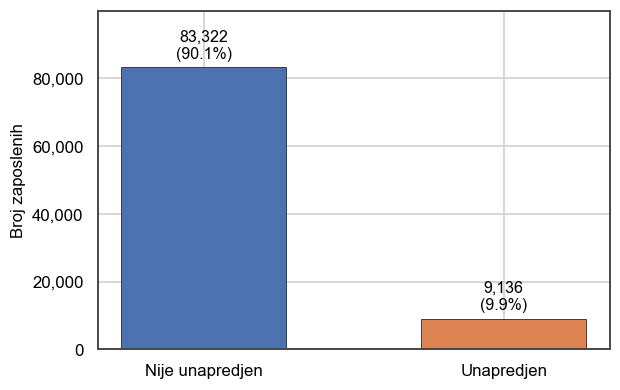

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

brojevi = y.value_counts().sort_index()
stubovi = ax.bar(['Nije unapredjen', 'Unapredjen'], brojevi.values,
                 color=[BOJA_NE, BOJA_DA], width=0.55,
                 edgecolor='#333333', linewidth=0.6)

for stub, n in zip(stubovi, brojevi.values):
    ax.text(stub.get_x() + stub.get_width() / 2, n + brojevi.max() * 0.02,
            f'{n:,}\n({n / len(y) * 100:.1f}%)', ha='center', va='bottom', fontsize=10.5)

ax.set_ylabel('Broj zaposlenih')
ax.set_ylim(0, brojevi.max() * 1.20)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))

sacuvaj('slika_01_disbalans_klasa')
plt.show()

### A3.4 Referentne tačke — modeli bez predikcione moći

In [11]:
p = y.mean()

print('Model koji SVE proglasi NEUNAPREDJENIM:')
print(f'  Accuracy  = {1 - p:.4f}   <- izgleda odlicno, a model je bezvredan')
print(f'  Recall    = 0.0000')
print(f'  F1        = 0.0000')
print()
print('Model koji SVE proglasi UNAPREDJENIM:')
print(f'  Accuracy  = {p:.4f}')
print(f'  Precision = {p:.4f}')
print(f'  Recall    = 1.0000')
print(f'  F1        = {2 * p / (1 + p):.4f}   <- referentna tacka za nas F1')

Model koji SVE proglasi NEUNAPREDJENIM:
  Accuracy  = 0.9012   <- izgleda odlicno, a model je bezvredan
  Recall    = 0.0000
  F1        = 0.0000

Model koji SVE proglasi UNAPREDJENIM:
  Accuracy  = 0.0988
  Precision = 0.0988
  Recall    = 1.0000
  F1        = 0.1799   <- referentna tacka za nas F1


# B — Eksplorativna analiza podataka
## B1 — Deskriptivna statistika
### B1.1 — Numerički atributi


In [12]:
TABELE = Path('tabele')
TABELE.mkdir(exist_ok=True)

num_atributi = X.select_dtypes(include=np.number)

opis = num_atributi.describe().T
opis['Asimetrija'] = num_atributi.skew()
opis = opis.rename(columns={
    'count': 'N', 'mean': 'Sredina', 'std': 'St. dev.', 'min': 'Min',
    '25%': 'Q1', '50%': 'Medijana', '75%': 'Q3', 'max': 'Max',
})
opis = opis[['N', 'Sredina', 'St. dev.', 'Min', 'Q1', 'Medijana', 'Q3', 'Max', 'Asimetrija']].round(2)
opis['N'] = opis['N'].astype(int)

opis.to_csv(TABELE / 'tabela_02_deskriptivna_statistika.csv',
            encoding='utf-8-sig', index_label='Atribut')
print(f'Sacuvano: tabele/tabela_02_deskriptivna_statistika.csv  ({len(opis)} atributa)')
opis

Sacuvano: tabele/tabela_02_deskriptivna_statistika.csv  (35 atributa)


,N,Sredina,St. dev.,Min,Q1,Medijana,Q3,Max,Asimetrija
age,92458,40.92,10.79,22.00,32.00,41.00,50.00,59.00,-0.03
years_at_company,92458,5.33,3.31,0.00,3.00,5.00,7.00,30.00,1.08
years_in_current_role,92458,2.67,2.63,0.00,1.00,2.00,4.00,25.00,1.47
years_since_last_promotion,92458,2.67,2.63,0.00,1.00,2.00,4.00,29.00,1.50
team_size,92458,11.01,4.91,3.00,7.00,11.00,15.00,19.00,-0.01
performance_score,92458,70.11,14.72,40.00,59.51,69.99,80.61,100.00,0.02
performance_last_year,92458,68.17,13.88,40.00,58.35,68.04,77.81,100.00,0.07
performance_two_years_ago,92458,65.10,11.79,40.00,56.94,65.01,73.14,100.00,0.09
manager_rating,92458,3.30,0.77,1.00,2.77,3.30,3.84,5.00,-0.04
peer_feedback_score,92458,3.49,0.82,1.00,2.93,3.51,4.09,5.00,-0.16


### B1.2 — Kategorijski atributi


In [13]:
redovi = []
for kol in X.select_dtypes(include='object').columns:
    for vrednost, broj in X[kol].value_counts().items():
        redovi.append({
            'Atribut': kol,
            'Kategorija': vrednost,
            'Broj': broj,
            'Udeo (%)': round(broj / len(X) * 100, 2),
            'Stopa unapredjenja (%)': round(df.loc[X[kol] == vrednost, TARGET].mean() * 100, 2),
        })

kat_opis = pd.DataFrame(redovi)
kat_opis.to_csv(TABELE / 'tabela_03_kategorijski_atributi.csv', index=False, encoding='utf-8-sig')
print('Sacuvano: tabele/tabela_03_kategorijski_atributi.csv')
kat_opis

Sacuvano: tabele/tabela_03_kategorijski_atributi.csv


,Atribut,Kategorija,Broj,Udeo (%),Stopa unapredjenja (%)
0,gender,Female,46259,50.03,9.64
1,gender,Male,46199,49.97,10.12
2,education_level,Bachelor,59823,64.70,9.77
3,education_level,Master,27866,30.14,10.04
4,education_level,PhD,4769,5.16,10.38
5,marital_status,Single,46357,50.14,9.86
6,marital_status,Married,46101,49.86,9.91
7,city_tier,Tier1,37255,40.29,9.88
8,city_tier,Tier2,32253,34.88,9.87
9,city_tier,Tier3,22950,24.82,9.90


### B1.3 — Dva nalaza koja izvlačimo iz tabele

In [14]:
print('RASPON SKALA')
print(f"  najmanja st. devijacija: {opis['St. dev.'].min():>10.3f}   ({opis['St. dev.'].idxmin()})")
print(f"  najveca  st. devijacija: {opis['St. dev.'].max():>10.1f}   ({opis['St. dev.'].idxmax()})")
print(f"  odnos 1 : {opis['St. dev.'].max() / opis['St. dev.'].min():,.0f}")
print()
print('ATRIBUTI SA IZRAZENOM ASIMETRIJOM (|asimetrija| > 1)')
asim = opis['Asimetrija'][opis['Asimetrija'].abs() > 1].sort_values(key=abs, ascending=False)
print(asim.to_string())

RASPON SKALA
  najmanja st. devijacija:      0.050   (attendance_rate)
  najveca  st. devijacija:    21129.0   (salary)
  odnos 1 : 422,579

ATRIBUTI SA IZRAZENOM ASIMETRIJOM (|asimetrija| > 1)
years_since_last_promotion    1.50
years_in_current_role         1.47
years_at_company              1.08


## B2 — Kategorijska obeležja i stopa unapređenja
### B2.1 — Stopa unapređenja po sektorima

Sacuvano: slike/slika_02_stopa_po_sektorima.png


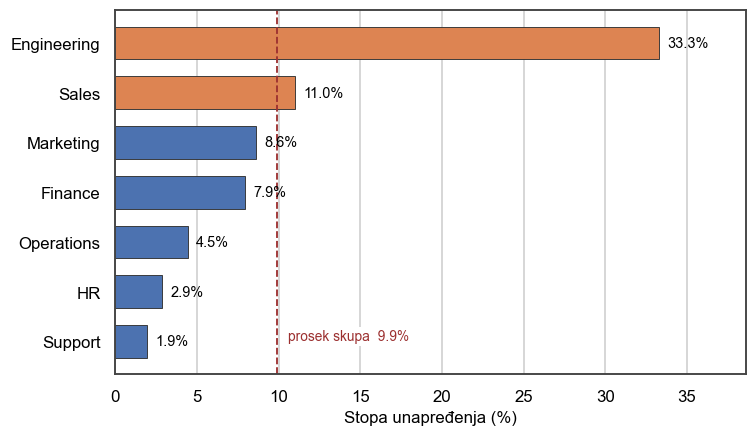

In [15]:
prosek = y.mean() * 100
CRVENA = '#9c3030'

stopa = df.groupby('department')[TARGET].mean().sort_values() * 100

fig, ax = plt.subplots(figsize=(7.4, 4.3))
boje = [BOJA_DA if v > prosek else BOJA_NE for v in stopa.values]
stubovi = ax.barh(stopa.index, stopa.values, color=boje,
                  edgecolor='#333333', linewidth=0.6, height=0.66)

for stub, v in zip(stubovi, stopa.values):
    ax.text(v + 0.5, stub.get_y() + stub.get_height() / 2,
            f'{v:.1f}%', va='center', fontsize=9.5)

ax.axvline(prosek, color=CRVENA, ls='--', lw=1.2)
ax.text(prosek + 0.7, 0.10, f'prosek skupa  {prosek:.1f}%',
        color=CRVENA, fontsize=9, va='center',
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5))

ax.set_xlabel('Stopa unapređenja (%)')
ax.set_xlim(0, stopa.max() * 1.16)
ax.grid(axis='y', visible=False)

sacuvaj('slika_02_stopa_po_sektorima')
plt.show()

### B2.2 — Ostali kategorijski atributi

Sacuvano: slike/slika_03_stopa_po_kategorijama.png


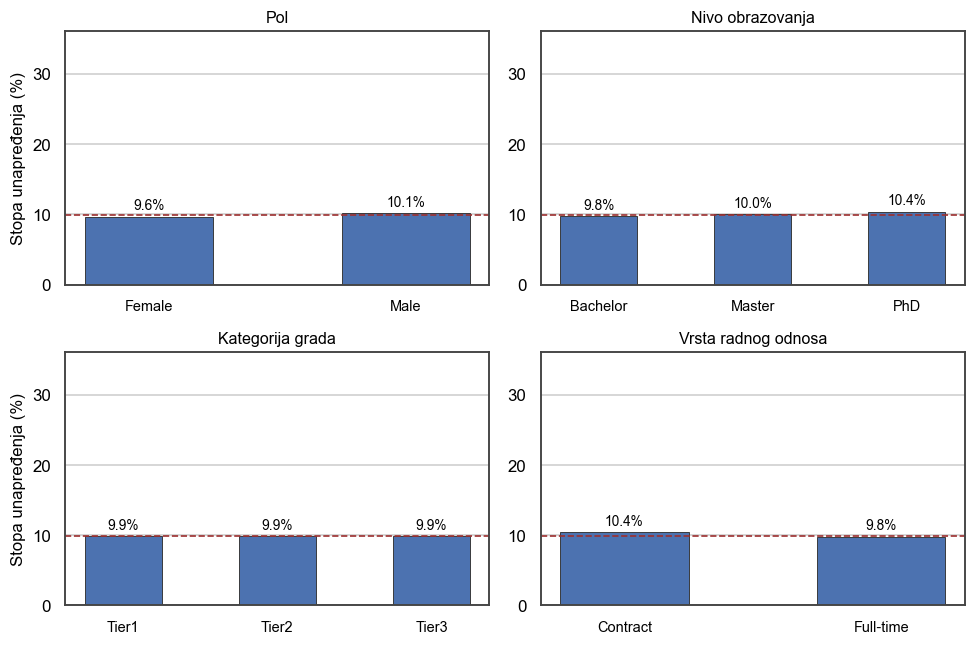

In [16]:
ostali = ['gender', 'education_level', 'city_tier', 'employment_type']
naslovi = ['Pol', 'Nivo obrazovanja', 'Kategorija grada', 'Vrsta radnog odnosa']

fig, axes = plt.subplots(2, 2, figsize=(9, 6))

for ax, kol, nas in zip(axes.ravel(), ostali, naslovi):
    s = df.groupby(kol)[TARGET].mean() * 100
    ax.bar(s.index, s.values, color=BOJA_NE, width=0.5,
           edgecolor='#333333', linewidth=0.6)
    ax.axhline(prosek, color=CRVENA, ls='--', lw=1.1)
    for i, v in enumerate(s.values):
        ax.text(i, v + 1.0, f'{v:.1f}%', ha='center', fontsize=9)
    ax.set_ylim(0, 36)          # ista skala kao Slika 2 - namerno
    ax.set_title(nas, fontsize=10.5, pad=6)
    ax.set_ylabel('Stopa unapređenja (%)' if kol in ('gender', 'city_tier') else '')
    ax.grid(axis='x', visible=False)
    ax.tick_params(axis='x', labelsize=9.5)

fig.tight_layout()
sacuvaj('slika_03_stopa_po_kategorijama')
plt.show()

## B3 — Raspodele numeričkih atributa po klasama
### B3.1 — Poređenje klasa

In [17]:
num_atributi = X.select_dtypes(include=np.number)

g0 = num_atributi[y == 0]
g1 = num_atributi[y == 1]
n0, n1 = len(g0), len(g1)

# objedinjena standardna devijacija - imenilac Cohenovog d
sp = np.sqrt(((n0 - 1) * g0.var() + (n1 - 1) * g1.var()) / (n0 + n1 - 2))

poredjenje = pd.DataFrame({
    'Nije unapredjen': g0.mean(),
    'Unapredjen': g1.mean(),
    'Razlika': g1.mean() - g0.mean(),
    'Cohen d': (g1.mean() - g0.mean()) / sp,
}).sort_values('Cohen d', key=abs, ascending=False).round(3)

poredjenje.to_csv(TABELE / 'tabela_04_poredjenje_po_klasama.csv',
                  encoding='utf-8-sig', index_label='Atribut')
print('Sacuvano: tabele/tabela_04_poredjenje_po_klasama.csv')
poredjenje.head(15)

Sacuvano: tabele/tabela_04_poredjenje_po_klasama.csv


,Nije unapredjen,Unapredjen,Razlika,Cohen d
performance_score,69.140,78.914,9.774,0.677
projects_completed,4.907,6.572,1.666,0.625
kpi_achievement_percent,68.890,78.881,9.991,0.593
tasks_completed,34.539,42.811,8.273,0.568
manager_rating,3.262,3.664,0.402,0.532
bonus_last_year,10297.986,11469.403,1171.417,0.513
salary,96453.929,106814.381,10360.452,0.496
peer_feedback_score,3.457,3.833,0.376,0.464
leadership_score,57.645,63.031,5.385,0.443
stock_options,5614.698,6051.413,436.715,0.347


### B3.2 — Pomoćna funkcija za mreže kutijastih dijagrama

In [18]:
df_plot = df.copy()
df_plot['klasa'] = np.where(y == 1, 'Unapređen', 'Nije unapređen')

REDOSLED = ['Nije unapređen', 'Unapređen']
PALETA = {'Nije unapređen': BOJA_NE, 'Unapređen': BOJA_DA}


def mreza_kutija(atributi, nazivi, redova, kolona, ime, sirina, visina):
    fig, axes = plt.subplots(redova, kolona, figsize=(sirina, visina))
    for ax, kol, naz in zip(np.ravel(axes), atributi, nazivi):
        sns.boxplot(data=df_plot, x='klasa', y=kol, hue='klasa',
                    order=REDOSLED, hue_order=REDOSLED, palette=PALETA,
                    legend=False, showfliers=False, width=0.55, linewidth=0.9, ax=ax)
        ax.set_title(naz, fontsize=10, pad=5)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='both', labelsize=8.5)
        ax.grid(axis='x', visible=False)
        ax.text(0.97, 0.05, f"d = {poredjenje.loc[kol, 'Cohen d']:.2f}".replace('.', ','),
                transform=ax.transAxes, ha='right', va='bottom', fontsize=8.5,
                color='#1f3352', weight='bold',
                bbox=dict(facecolor='white', edgecolor='#c9d2dd', pad=2, linewidth=0.6))
    fig.tight_layout()
    sacuvaj(ime)
    plt.show()

### B3.3 — Osam najjačih atributa

Sacuvano: slike/slika_04_raspodele_jaki_atributi.png


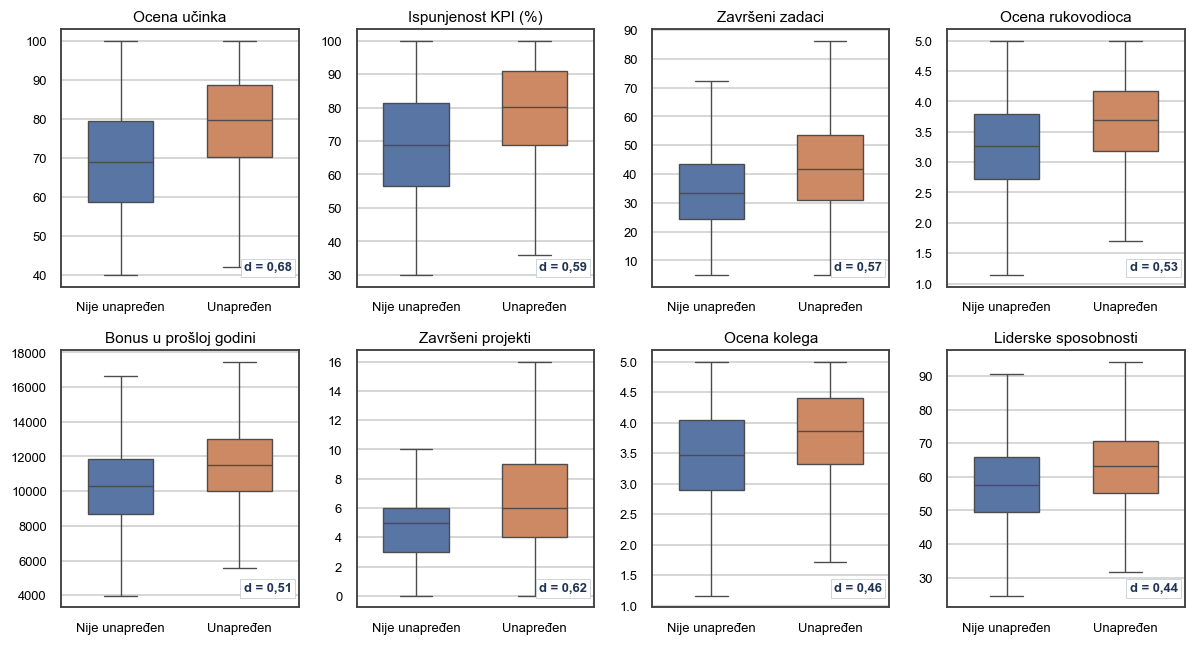

In [19]:
JAKI = ['performance_score', 'kpi_achievement_percent', 'tasks_completed', 'manager_rating',
        'bonus_last_year', 'projects_completed', 'peer_feedback_score', 'leadership_score']
JAKI_NAZ = ['Ocena učinka', 'Ispunjenost KPI (%)', 'Završeni zadaci', 'Ocena rukovodioca',
            'Bonus u prošloj godini', 'Završeni projekti', 'Ocena kolega', 'Liderske sposobnosti']

mreza_kutija(JAKI, JAKI_NAZ, 2, 4, 'slika_04_raspodele_jaki_atributi', 11.0, 6.0)

### B3.4 — Četiri atributa bez uticaja

Sacuvano: slike/slika_05_raspodele_slabi_atributi.png


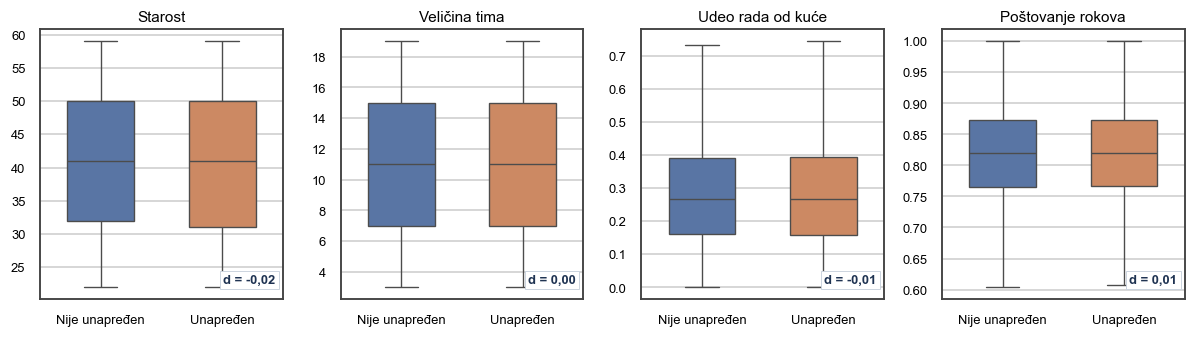

In [20]:
SLABI = ['age', 'team_size', 'remote_work_ratio', 'deadline_adherence_rate']
SLABI_NAZ = ['Starost', 'Veličina tima', 'Udeo rada od kuće', 'Poštovanje rokova']

mreza_kutija(SLABI, SLABI_NAZ, 1, 4, 'slika_05_raspodele_slabi_atributi', 11.0, 3.2)

## B4 - KORELACIONA MATRICA I MULTIKOLINEARNOST
### B4.1 — Korelaciona matrica

Sacuvano: slike/slika_06_korelaciona_matrica.png


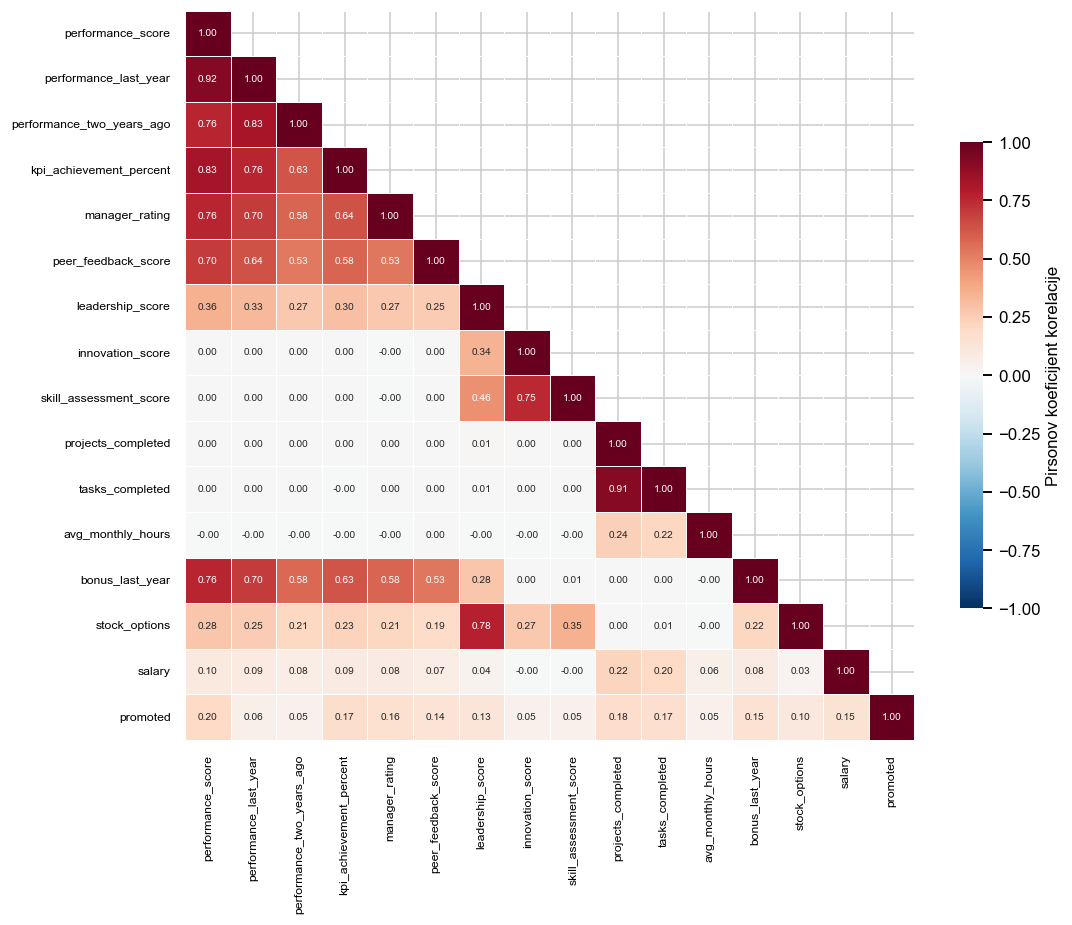

In [21]:
KLJUCNI = [
    'performance_score', 'performance_last_year', 'performance_two_years_ago',
    'kpi_achievement_percent', 'manager_rating', 'peer_feedback_score',
    'leadership_score', 'innovation_score', 'skill_assessment_score',
    'projects_completed', 'tasks_completed', 'avg_monthly_hours',
    'bonus_last_year', 'stock_options', 'salary', TARGET,
]

C = df[KLJUCNI].corr()
maska = np.triu(np.ones_like(C, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10.2, 8.6))
sns.heatmap(C, mask=maska, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'fontsize': 6.6},
            linewidths=0.5, linecolor='white', square=True,
            cbar_kws={'shrink': 0.62, 'label': 'Pirsonov koeficijent korelacije'}, ax=ax)
ax.tick_params(axis='x', labelsize=8, rotation=90)
ax.tick_params(axis='y', labelsize=8, rotation=0)

fig.tight_layout()
sacuvaj('slika_06_korelaciona_matrica')
plt.show()

### B4.2 — Pune korelacije i visoki parovi

In [22]:
C_sve = num_atributi.corr()

C_sve.round(3).to_csv(TABELE / 'tabela_05_korelaciona_matrica.csv',
                      encoding='utf-8-sig', index_label='Atribut')

gornji = C_sve.where(np.triu(np.ones(C_sve.shape), k=1).astype(bool)).stack()
parovi = (gornji[gornji.abs() > 0.7]
          .sort_values(key=abs, ascending=False)
          .rename('Korelacija')
          .reset_index())
parovi.columns = ['Atribut 1', 'Atribut 2', 'Korelacija']
parovi['Korelacija'] = parovi['Korelacija'].round(3)

parovi.to_csv(TABELE / 'tabela_06_visoke_korelacije.csv', index=False, encoding='utf-8-sig')
print(f'Parova sa |r| > 0,7: {len(parovi)}')
parovi

Parova sa |r| > 0,7: 11


,Atribut 1,Atribut 2,Korelacija
0,performance_score,performance_last_year,0.918
1,projects_completed,tasks_completed,0.914
2,performance_score,kpi_achievement_percent,0.828
3,performance_last_year,performance_two_years_ago,0.828
4,leadership_score,stock_options,0.775
5,performance_score,manager_rating,0.765
6,performance_score,bonus_last_year,0.762
7,performance_score,performance_two_years_ago,0.761
8,performance_last_year,kpi_achievement_percent,0.759
9,innovation_score,skill_assessment_score,0.754


### B4.3 — VIF

In [23]:
X_vif = sm.add_constant(num_atributi)

vif = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
                index=X_vif.columns).drop('const')

vif_tabela = pd.DataFrame({'VIF': vif, 'koren_VIF': np.sqrt(vif)})
vif_tabela = vif_tabela.sort_values('VIF', ascending=False).round(3)

vif_tabela.to_csv(TABELE / 'tabela_07_vif.csv', encoding='utf-8-sig', index_label='Atribut')

print(f'Atributa sa korenom VIF > 2 : {(vif_tabela["koren_VIF"] > 2).sum()} od {len(vif_tabela)}')
print(f'Medijana korena VIF         : {vif_tabela["koren_VIF"].median():.3f}')
print()
print(vif_tabela.head(8).to_string())

Atributa sa korenom VIF > 2 : 4 od 35
Medijana korena VIF         : 1.123

                              VIF  koren_VIF
performance_score          12.573      3.546
performance_last_year       8.558      2.925
projects_completed          6.441      2.538
tasks_completed             6.050      2.460
skill_assessment_score      3.364      1.834
kpi_achievement_percent     3.187      1.785
performance_two_years_ago   3.181      1.783
leadership_score            3.032      1.741


# C - Priprema za modelovanje

## C1 — Podela na 80/20 - train i test skup

In [24]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Trening skup : {len(X_train):,} ({len(X_train) / len(X) * 100:.0f}%)')
print(f'Test skup    : {len(X_test):,} ({len(X_test) / len(X) * 100:.0f}%)')
print()
print('Udeo unapredjenih:')
print(f'  ceo skup : {y.mean() * 100:.2f}%')
print(f'  trening  : {y_train.mean() * 100:.2f}%')
print(f'  test     : {y_test.mean() * 100:.2f}%')
print()
print(f'Broj unapredjenih u treningu: {y_train.sum():,}')
print(f'Broj unapredjenih u testu   : {y_test.sum():,}')

Trening skup : 73,966 (80%)
Test skup    : 18,492 (20%)

Udeo unapredjenih:
  ceo skup : 9.88%
  trening  : 9.88%
  test     : 9.88%

Broj unapredjenih u treningu: 7,309
Broj unapredjenih u testu   : 1,827


## C2 - Iterativna VIF eliminacija

In [25]:
PRAG_VIF = 2   # granica za koren VIF-a, prema metodologiji sa veštačke

num_kolone = X_train.select_dtypes(include=np.number).columns.tolist()
kat_kolone = X_train.select_dtypes(include='object').columns.tolist()


def koren_vif(podaci):
    X_sa_konstantom = sm.add_constant(podaci)
    vrednosti = [variance_inflation_factor(X_sa_konstantom.values, i)
                 for i in range(X_sa_konstantom.shape[1])]
    return np.sqrt(pd.Series(vrednosti, index=X_sa_konstantom.columns).drop('const'))


preostali = num_kolone.copy()
koraci = []

# Iterativni postupak: uklanja se samo atribut sa najvisom vrednoscu,
# pa se VIF racuna ponovo nad preostalim atributima
while True:
    sq = koren_vif(X_train[preostali]).sort_values(ascending=False)
    if sq.iloc[0] <= PRAG_VIF:
        break
    koraci.append({
        'Korak': len(koraci) + 1,
        'Uklonjen atribut': sq.index[0],
        'Koren VIF': round(sq.iloc[0], 3),
        'Atributa iznad praga': int((sq > PRAG_VIF).sum()),
    })
    preostali.remove(sq.index[0])

eliminacija = pd.DataFrame(koraci)
eliminacija.to_csv(TABELE / 'tabela_08_vif_eliminacija.csv', index=False, encoding='utf-8-sig')

ATRIBUTI_LOGREG = preostali + kat_kolone
ATRIBUTI_STABLA = num_kolone + kat_kolone

print(eliminacija.to_string(index=False))
print(f'\nNajveci koren VIF na kraju: {koren_vif(X_train[preostali]).max():.3f}')
print()
print(f'Logisticka regresija : {len(ATRIBUTI_LOGREG)} atributa')
print(f'RF i XGBoost         : {len(ATRIBUTI_STABLA)} atributa')

 Korak      Uklonjen atribut  Koren VIF  Atributa iznad praga
     1     performance_score      3.542                     4
     2    projects_completed      2.543                     3
     3 performance_last_year      2.408                     1

Najveci koren VIF na kraju: 1.828

Logisticka regresija : 38 atributa
RF i XGBoost         : 41 atributa


## C3 - Pretprocesiranje

In [26]:
def napravi_pretprocesor(atributi):
    return ColumnTransformer([
        ('num', StandardScaler(), [a for a in atributi if a in num_kolone]),
        ('kat', OneHotEncoder(handle_unknown='ignore', drop='first'),
                [a for a in atributi if a in kat_kolone]),
    ])


pretprocesor_logreg = napravi_pretprocesor(ATRIBUTI_LOGREG)
pretprocesor_stabla = napravi_pretprocesor(ATRIBUTI_STABLA)

for naziv, pre, atr in [('LogReg', pretprocesor_logreg, ATRIBUTI_LOGREG),
                        ('RF/XGB', pretprocesor_stabla, ATRIBUTI_STABLA)]:
    izlaz = pre.fit_transform(X_train[atr])
    print(f'{naziv:8s} ulaz {len(atr):>3} atributa  ->  izlaz {izlaz.shape[1]:>3} kolona')

LogReg   ulaz  38 atributa  ->  izlaz  45 kolona
RF/XGB   ulaz  41 atributa  ->  izlaz  48 kolona


## C4 - Strategija unakrsne validacije, Funkcija za evaluaciju, Skladištenje

In [27]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

MODELI = Path('modeli')
MODELI.mkdir(exist_ok=True)

rezultati = []
verovatnoce_modela = {}


def oceni_model(naziv, algoritam, varijanta, model, atributi, prag=0.5):
    verovatnoce = model.predict_proba(X_test[atributi])[:, 1]
    predikcije = (verovatnoce >= prag).astype(int)

    red = {
        'Model': naziv,
        'Algoritam': algoritam,
        'Varijanta': varijanta,
        'Accuracy': accuracy_score(y_test, predikcije),
        'Precision': precision_score(y_test, predikcije, zero_division=0),
        'Recall': recall_score(y_test, predikcije),
        'F1': f1_score(y_test, predikcije),
        'ROC-AUC': roc_auc_score(y_test, verovatnoce),
    }

    rezultati.append(red)
    verovatnoce_modela[naziv] = verovatnoce
    joblib.dump(model, MODELI / f'{naziv}.joblib')

    print(naziv)
    for mera in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
        print(f'   {mera:10s} {red[mera]:.4f}')
    return red


print(f'Unakrsna validacija : {CV.get_n_splits()} preklopa, stratifikovano')
print(f'Metrike             : {", ".join(SCORING)}')
print(f'Folder za modele    : {MODELI}/')

Unakrsna validacija : 5 preklopa, stratifikovano
Metrike             : accuracy, precision, recall, f1, roc_auc
Folder za modele    : modeli/


---
# D - Kreiranje modela

## D1 — Logistička regresija: osnovni i balansirani - prvi i drugi model

In [28]:

# --- Model 1: osnovna logisticka regresija ---



lr_osnovni = Pipeline([
    ('pre', napravi_pretprocesor(ATRIBUTI_LOGREG)),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
lr_osnovni.fit(X_train[ATRIBUTI_LOGREG], y_train)
oceni_model('LR osnovni', 'Logisticka regresija', 'osnovni',
            lr_osnovni, ATRIBUTI_LOGREG)

print()





# --- Model 2: sa balansiranjem klasa ---



lr_balansirani = Pipeline([
    ('pre', napravi_pretprocesor(ATRIBUTI_LOGREG)),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced',
                                 random_state=RANDOM_STATE)),
])
lr_balansirani.fit(X_train[ATRIBUTI_LOGREG], y_train)
oceni_model('LR balansirani', 'Logisticka regresija', 'balansirani',
            lr_balansirani, ATRIBUTI_LOGREG)

LR osnovni
   Accuracy   0.9120
   Precision  0.6448
   Recall     0.2425
   F1         0.3524
   ROC-AUC    0.8658

LR balansirani
   Accuracy   0.7766
   Precision  0.2784
   Recall     0.7920
   F1         0.4120
   ROC-AUC    0.8656


{'Model': 'LR balansirani',
 'Algoritam': 'Logisticka regresija',
 'Varijanta': 'balansirani',
 'Accuracy': 0.7766060999351071,
 'Precision': 0.2783762985763755,
 'Recall': 0.7920087575259989,
 'F1': 0.4119572953736655,
 'ROC-AUC': 0.8655957221337897}

## D2 - Podešavanje hiperparametara Logističke Regresije - treći model

In [29]:

mreza_lr = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__class_weight': [None, 'balanced'],
    'model__solver': ['liblinear'],
}

pretraga_lr = GridSearchCV(
    Pipeline([
        ('pre', napravi_pretprocesor(ATRIBUTI_LOGREG)),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    param_grid=mreza_lr,
    scoring=SCORING,
    refit='f1',
    cv=CV,
    n_jobs=-1,
)

pretraga_lr.fit(X_train[ATRIBUTI_LOGREG], y_train)

print('Najbolji parametri:',
      {k.replace('model__', ''): v for k, v in pretraga_lr.best_params_.items()})
print(f'Najbolji F1 iz unakrsne validacije: {pretraga_lr.best_score_:.4f}')
print()

oceni_model('LR podeseni', 'Logisticka regresija', 'podeseni',
            pretraga_lr.best_estimator_, ATRIBUTI_LOGREG)

Najbolji parametri: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Najbolji F1 iz unakrsne validacije: 0.4083

LR podeseni
   Accuracy   0.7765
   Precision  0.2783
   Recall     0.7920
   F1         0.4118
   ROC-AUC    0.8656


{'Model': 'LR podeseni',
 'Algoritam': 'Logisticka regresija',
 'Varijanta': 'podeseni',
 'Accuracy': 0.7764979450573221,
 'Precision': 0.27826923076923077,
 'Recall': 0.7920087575259989,
 'F1': 0.4118400455386367,
 'ROC-AUC': 0.865611224505045}

### TABELA REZULTATA ZA LR

In [30]:
rez_lr = pd.DataFrame(pretraga_lr.cv_results_)[[
    'param_model__C', 'param_model__penalty', 'param_model__class_weight',
    'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall',
    'mean_test_f1', 'mean_test_roc_auc',
]].sort_values('mean_test_f1', ascending=False).round(4)

rez_lr.columns = ['C', 'penalty', 'class_weight',
                  'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

rez_lr.to_csv(TABELE / 'tabela_09_pretraga_logreg.csv',
              index=False, encoding='utf-8-sig')
print(f'Sacuvano: tabele/tabela_09_pretraga_logreg.csv ({len(rez_lr)} kombinacija)')
rez_lr.head(10)

Sacuvano: tabele/tabela_09_pretraga_logreg.csv (20 kombinacija)


,C,penalty,class_weight,Accuracy,Precision,Recall,F1,ROC-AUC
11,1.00,l2,balanced,0.7760,0.2763,0.7822,0.4083,0.8599
18,100.00,l1,balanced,0.7761,0.2763,0.7818,0.4083,0.8599
19,100.00,l2,balanced,0.7761,0.2763,0.7818,0.4083,0.8599
14,10.00,l1,balanced,0.7761,0.2763,0.7818,0.4082,0.8599
15,10.00,l2,balanced,0.7760,0.2762,0.7818,0.4082,0.8599
10,1.00,l1,balanced,0.7760,0.2762,0.7816,0.4081,0.8599
6,0.10,l1,balanced,0.7757,0.2759,0.7818,0.4079,0.8599
7,0.10,l2,balanced,0.7750,0.2752,0.7816,0.4071,0.8598
2,0.01,l1,balanced,0.7724,0.2726,0.7811,0.4042,0.8584
3,0.01,l2,balanced,0.7680,0.2680,0.7788,0.3988,0.8558


## D3 - Random Forest: osnovni i balansirani model - prvi i drugi

In [31]:


# --- Model 4: osnovni Random Forest ---
rf_osnovni = Pipeline([
    ('pre', napravi_pretprocesor(ATRIBUTI_STABLA)),
    ('model', RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                     random_state=RANDOM_STATE)),
])
rf_osnovni.fit(X_train[ATRIBUTI_STABLA], y_train)
oceni_model('RF osnovni', 'Random Forest', 'osnovni',
            rf_osnovni, ATRIBUTI_STABLA)

print()






# --- Model 5: sa balansiranjem klasa ---
rf_balansirani = Pipeline([
    ('pre', napravi_pretprocesor(ATRIBUTI_STABLA)),
    ('model', RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                     class_weight='balanced',
                                     random_state=RANDOM_STATE)),
])
rf_balansirani.fit(X_train[ATRIBUTI_STABLA], y_train)
oceni_model('RF balansirani', 'Random Forest', 'balansirani',
            rf_balansirani, ATRIBUTI_STABLA)

RF osnovni
   Accuracy   0.9055
   Precision  0.8264
   Recall     0.0547
   F1         0.1027
   ROC-AUC    0.8688

RF balansirani
   Accuracy   0.9059
   Precision  0.8480
   Recall     0.0580
   F1         0.1086
   ROC-AUC    0.8846


{'Model': 'RF balansirani',
 'Algoritam': 'Random Forest',
 'Varijanta': 'balansirani',
 'Accuracy': 0.9059052563270603,
 'Precision': 0.848,
 'Recall': 0.058018609742747675,
 'F1': 0.10860655737704918,
 'ROC-AUC': 0.8845634809786397}

### Oslobadjanje memorije (podešavanje hiperparametara RF je iziskivalo više prostora)

In [32]:
import gc
import psutil

for ime in ['lr_osnovni', 'lr_balansirani', 'rf_osnovni', 'rf_balansirani']:
    globals().pop(ime, None)
gc.collect()

print(f'Slobodno RAM-a: {psutil.virtual_memory().available / 1024**3:.2f} GB')

Slobodno RAM-a: 0.33 GB


## D4 — Podešavanje hiperparametara Random Forest-a - treći model

In [33]:
put_pretrage = MODELI / 'pretraga_rf.joblib'

if put_pretrage.exists():
    pretraga_rf = joblib.load(put_pretrage)
    print('Ucitana ranije izvrsena pretraga (skripta pretraga_rf.py).')
else:
    pretraga_rf = GridSearchCV(
        Pipeline([
            ('pre', napravi_pretprocesor(ATRIBUTI_STABLA)),
            ('model', RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                             random_state=RANDOM_STATE)),
        ], memory='kes_pipeline'),
        param_grid={
            'model__max_depth': [10, 20, None],
            'model__min_samples_leaf': [1, 20, 50],
            'model__class_weight': [None, 'balanced_subsample'],
        },
        scoring=SCORING, refit='f1', cv=CV, n_jobs=1, verbose=2,
    )
    pretraga_rf.fit(X_train[ATRIBUTI_STABLA], y_train)
    joblib.dump(pretraga_rf, put_pretrage, compress=3)

print('Najbolji parametri:',
      {k.replace('model__', ''): v for k, v in pretraga_rf.best_params_.items()})
print(f'Najbolji F1 iz unakrsne validacije: {pretraga_rf.best_score_:.4f}')
print()

oceni_model('RF podeseni', 'Random Forest', 'podeseni',
            pretraga_rf.best_estimator_, ATRIBUTI_STABLA)

Ucitana ranije izvrsena pretraga (skripta pretraga_rf.py).
Najbolji parametri: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'min_samples_leaf': 20}
Najbolji F1 iz unakrsne validacije: 0.4823

RF podeseni
   Accuracy   0.8863
   Precision  0.4417
   Recall     0.5720
   F1         0.4984
   ROC-AUC    0.8868


{'Model': 'RF podeseni',
 'Algoritam': 'Random Forest',
 'Varijanta': 'podeseni',
 'Accuracy': 0.886275146009085,
 'Precision': 0.44167371090448015,
 'Recall': 0.571975916803503,
 'F1': 0.49844979728118294,
 'ROC-AUC': 0.8867619766902799}

### TABELA REZULTATA ZA RF


In [34]:
rez_rf = pd.DataFrame(pretraga_rf.cv_results_)[[
    'param_model__max_depth',
    'param_model__min_samples_leaf',
    'param_model__class_weight',
    'mean_test_accuracy',
    'mean_test_precision',
    'mean_test_recall',
    'mean_test_f1',
    'mean_test_roc_auc',
]].sort_values('mean_test_f1', ascending=False).round(4)

rez_rf.columns = ['max_depth', 'min_samples_leaf', 'class_weight',
                  'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

rez_rf.to_csv(TABELE / 'tabela_10_pretraga_rf.csv', index=False, encoding='utf-8-sig')
print(f'Sacuvano: tabele/tabela_10_pretraga_rf.csv ({len(rez_rf)} kombinacija)')
rez_rf.head(10)

Sacuvano: tabele/tabela_10_pretraga_rf.csv (18 kombinacija)


,max_depth,min_samples_leaf,class_weight,Accuracy,Precision,Recall,F1,ROC-AUC
13,20,20,balanced_subsample,0.8807,0.4223,0.5625,0.4823,0.8771
16,None,20,balanced_subsample,0.8809,0.4224,0.5585,0.4809,0.8773
14,20,50,balanced_subsample,0.8348,0.3360,0.6874,0.4513,0.8675
17,None,50,balanced_subsample,0.8346,0.3356,0.6874,0.4510,0.8675
9,10,1,balanced_subsample,0.8327,0.3286,0.6645,0.4397,0.8584
10,10,20,balanced_subsample,0.8208,0.3155,0.6952,0.4340,0.8599
11,10,50,balanced_subsample,0.8061,0.2996,0.7194,0.4230,0.8583
12,20,1,balanced_subsample,0.9115,0.6858,0.1922,0.3003,0.8774
15,None,1,balanced_subsample,0.9053,0.8486,0.0508,0.0957,0.8817
3,20,1,None,0.9047,0.8538,0.0426,0.0810,0.8669


## D5 - XGBoost: osnovni i balansirani model - prvi i drugi

In [35]:


# odnos negativne i pozitivne klase u trening skupu
odnos_klasa = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {odnos_klasa:.2f}\n')




# --- Model 7: osnovni XGBoost ---
xgb_osnovni = Pipeline([
    ('pre', napravi_pretprocesor(ATRIBUTI_STABLA)),
    ('model', XGBClassifier(n_estimators=100, eval_metric='logloss',
                            n_jobs=-1, random_state=RANDOM_STATE)),
])
xgb_osnovni.fit(X_train[ATRIBUTI_STABLA], y_train)
oceni_model('XGB osnovni', 'XGBoost', 'osnovni',
            xgb_osnovni, ATRIBUTI_STABLA)

print()




# --- Model 8: sa scale_pos_weight ---
xgb_balansirani = Pipeline([
    ('pre', napravi_pretprocesor(ATRIBUTI_STABLA)),
    ('model', XGBClassifier(n_estimators=100, eval_metric='logloss',
                            scale_pos_weight=odnos_klasa,
                            n_jobs=-1, random_state=RANDOM_STATE)),
])
xgb_balansirani.fit(X_train[ATRIBUTI_STABLA], y_train)
oceni_model('XGB balansirani', 'XGBoost', 'balansirani',
            xgb_balansirani, ATRIBUTI_STABLA)

scale_pos_weight = 9.12

XGB osnovni
   Accuracy   0.9227
   Precision  0.6764
   Recall     0.4176
   F1         0.5164
   ROC-AUC    0.9275

XGB balansirani
   Accuracy   0.8863
   Precision  0.4543
   Recall     0.7515
   F1         0.5663
   ROC-AUC    0.9256


{'Model': 'XGB balansirani',
 'Algoritam': 'XGBoost',
 'Varijanta': 'balansirani',
 'Accuracy': 0.886275146009085,
 'Precision': 0.4543348775645268,
 'Recall': 0.7515051997810619,
 'F1': 0.5663023303773974,
 'ROC-AUC': 0.9256315615141153}

## D6 - Podešavanje hiperparametara XGBoost-a - treći model

In [36]:
mreza_xgb = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1, 0.3],
    'model__scale_pos_weight': [1, odnos_klasa],
}

pretraga_xgb = GridSearchCV(
    Pipeline([
        ('pre', napravi_pretprocesor(ATRIBUTI_STABLA)),
        ('model', XGBClassifier(eval_metric='logloss', n_jobs=-1,
                                random_state=RANDOM_STATE)),
    ]),
    param_grid=mreza_xgb,
    scoring=SCORING,
    refit='f1',
    cv=CV,
    n_jobs=1,
    verbose=2,
)

pretraga_xgb.fit(X_train[ATRIBUTI_STABLA], y_train)

print('Najbolji parametri:',
      {k.replace('model__', ''): v for k, v in pretraga_xgb.best_params_.items()})
print(f'Najbolji F1 iz unakrsne validacije: {pretraga_xgb.best_score_:.4f}')
print()

oceni_model('XGB podeseni', 'XGBoost', 'podeseni',
            pretraga_xgb.best_estimator_, ATRIBUTI_STABLA)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1; total time=   1.3s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1; total time=   0.9s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1; total time=   5.3s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1; total time=   1.3s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=1; total time=   2.0s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=9.119852236968121; total time=   1.5s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__n_estimators=100, model__scale_pos_weight=9.119852236968121; total time=   1.2s
[CV] END model__l

{'Model': 'XGB podeseni',
 'Algoritam': 'XGBoost',
 'Varijanta': 'podeseni',
 'Accuracy': 0.9027687648712956,
 'Precision': 0.5057884231536927,
 'Recall': 0.6934865900383141,
 'F1': 0.5849492151431209,
 'ROC-AUC': 0.9292205246797257}

### TABELA REZULTATA ZA XGBOOST

In [37]:
rez_xgb = pd.DataFrame(pretraga_xgb.cv_results_)[[
    'param_model__n_estimators', 'param_model__max_depth',
    'param_model__learning_rate', 'param_model__scale_pos_weight',
    'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall',
    'mean_test_f1', 'mean_test_roc_auc',
]].sort_values('mean_test_f1', ascending=False).round(4)

rez_xgb.columns = ['n_estimators', 'max_depth', 'learning_rate', 'scale_pos_weight',
                   'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

rez_xgb.to_csv(TABELE / 'tabela_11_pretraga_xgb.csv', index=False, encoding='utf-8-sig')
print(f'Sacuvano: tabele/tabela_11_pretraga_xgb.csv ({len(rez_xgb)} kombinacija)')
rez_xgb.head(10)

Sacuvano: tabele/tabela_11_pretraga_xgb.csv (36 kombinacija)


,n_estimators,max_depth,learning_rate,scale_pos_weight,Accuracy,Precision,Recall,F1,ROC-AUC
23,300,7,0.10,9.1199,0.9044,0.5127,0.6652,0.5790,0.9244
11,300,7,0.05,9.1199,0.8869,0.4564,0.7570,0.5695,0.9275
31,300,5,0.30,9.1199,0.9005,0.4973,0.6588,0.5667,0.9165
33,100,7,0.30,9.1199,0.9010,0.4994,0.6477,0.5639,0.9175
19,300,5,0.10,9.1199,0.8750,0.4290,0.7990,0.5583,0.9289
21,100,7,0.10,9.1199,0.8755,0.4294,0.7890,0.5561,0.9269
29,100,5,0.30,9.1199,0.8722,0.4215,0.7863,0.5488,0.9240
35,300,7,0.30,9.1199,0.9151,0.5784,0.5210,0.5482,0.9179
27,300,3,0.30,9.1199,0.8649,0.4083,0.8168,0.5444,0.9281
7,300,5,0.05,9.1199,0.8571,0.3950,0.8383,0.5370,0.9307


# E - Evaluacija rezultata
## E1 - Zbirna tabela

In [38]:
REDOSLED_ALG = ['Logisticka regresija', 'Random Forest', 'XGBoost']
REDOSLED_VAR = ['osnovni', 'balansirani', 'podeseni']

zbirna = pd.DataFrame(rezultati)
zbirna['Algoritam'] = pd.Categorical(zbirna['Algoritam'], REDOSLED_ALG, ordered=True)
zbirna['Varijanta'] = pd.Categorical(zbirna['Varijanta'], REDOSLED_VAR, ordered=True)
zbirna = zbirna.sort_values(['Algoritam', 'Varijanta']).reset_index(drop=True)

zbirna[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']] = \
    zbirna[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].round(4)

zbirna.to_csv(TABELE / 'tabela_12_zbirni_rezultati.csv',
              index=False, encoding='utf-8-sig')
print(f'Sacuvano: tabele/tabela_12_zbirni_rezultati.csv ({len(zbirna)} modela)')
print()

najbolji_f1 = zbirna.loc[zbirna['F1'].idxmax()]
najbolji_auc = zbirna.loc[zbirna['ROC-AUC'].idxmax()]
print(f"Najbolji po F1      : {najbolji_f1['Model']}  ({najbolji_f1['F1']:.4f})")
print(f"Najbolji po ROC-AUC : {najbolji_auc['Model']}  ({najbolji_auc['ROC-AUC']:.4f})")
print()
zbirna[['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']]

Sacuvano: tabele/tabela_12_zbirni_rezultati.csv (9 modela)

Najbolji po F1      : XGB podeseni  (0.5849)
Najbolji po ROC-AUC : XGB podeseni  (0.9292)



,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LR osnovni,0.9120,0.6448,0.2425,0.3524,0.8658
1,LR balansirani,0.7766,0.2784,0.7920,0.4120,0.8656
2,LR podeseni,0.7765,0.2783,0.7920,0.4118,0.8656
3,RF osnovni,0.9055,0.8264,0.0547,0.1027,0.8688
4,RF balansirani,0.9059,0.8480,0.0580,0.1086,0.8846
5,RF podeseni,0.8863,0.4417,0.5720,0.4984,0.8868
6,XGB osnovni,0.9227,0.6764,0.4176,0.5164,0.9275
7,XGB balansirani,0.8863,0.4543,0.7515,0.5663,0.9256
8,XGB podeseni,0.9028,0.5058,0.6935,0.5849,0.9292


### UPOREDNI PRIKAZ

Sacuvano: slike/slika_07_uporedni_prikaz.png


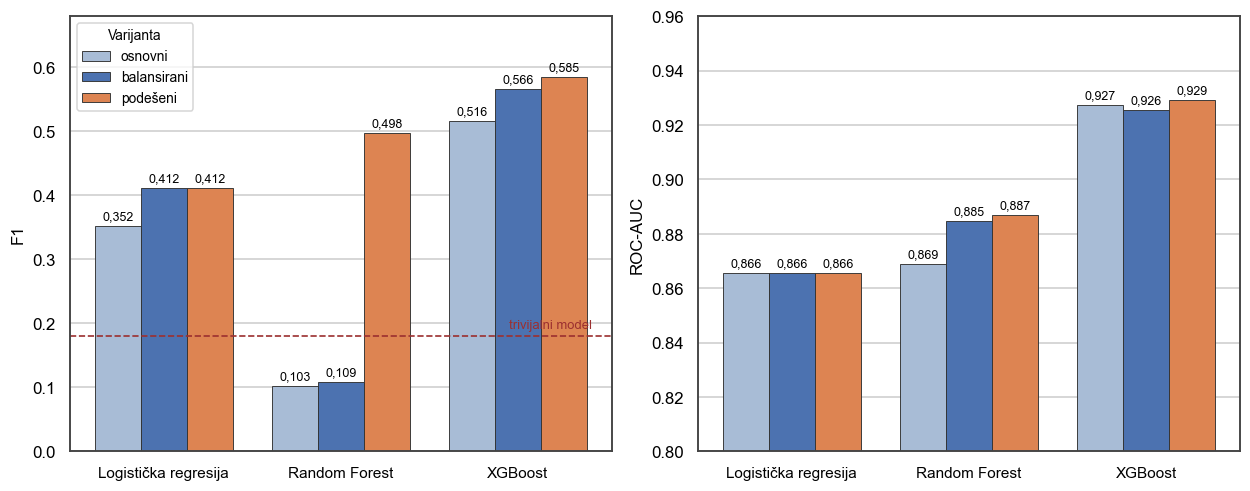

In [39]:
ALG = ['Logisticka regresija', 'Random Forest', 'XGBoost']
ALG_NAZ = ['Logistička regresija', 'Random Forest', 'XGBoost']
VAR = ['osnovni', 'balansirani', 'podeseni']
VAR_NAZ = ['osnovni', 'balansirani', 'podešeni']
BOJE = ['#a8bcd6', '#4C72B0', '#DD8452']
F1_TRIVIJALNI = 2 * y.mean() / (1 + y.mean())      # model koji sve proglasi pozitivnim

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
x = np.arange(len(ALG))
sirina = 0.26

for ax, mera, opseg in [(axes[0], 'F1', (0, 0.68)),
                        (axes[1], 'ROC-AUC', (0.80, 0.96))]:
    for i, (v, naz, boja) in enumerate(zip(VAR, VAR_NAZ, BOJE)):
        vred = [zbirna[(zbirna.Algoritam == a) & (zbirna.Varijanta == v)][mera].iloc[0]
                for a in ALG]
        stubovi = ax.bar(x + (i - 1) * sirina, vred, sirina, label=naz, color=boja,
                         edgecolor='#333333', linewidth=0.6)
        for s, val in zip(stubovi, vred):
            ax.text(s.get_x() + s.get_width() / 2, val + (opseg[1] - opseg[0]) * 0.015,
                    f'{val:.3f}'.replace('.', ','), ha='center', fontsize=8.2)
    if mera == 'F1':
        ax.axhline(F1_TRIVIJALNI, color='#9c3030', ls='--', lw=1.1)
        ax.text(2.42, F1_TRIVIJALNI + 0.012, 'trivijalni model',
                color='#9c3030', fontsize=8.5, ha='right')
    ax.set_xticks(x)
    ax.set_xticklabels(ALG_NAZ, fontsize=10)
    ax.set_ylabel(mera)
    ax.set_ylim(*opseg)
    ax.grid(axis='x', visible=False)

axes[0].legend(title='Varijanta', fontsize=9, title_fontsize=9, loc='upper left')
fig.tight_layout()
sacuvaj('slika_07_uporedni_prikaz')
plt.show()

## E2 - ROC i PR krive

Sacuvano: slike/slika_08_roc_i_pr_krive.png


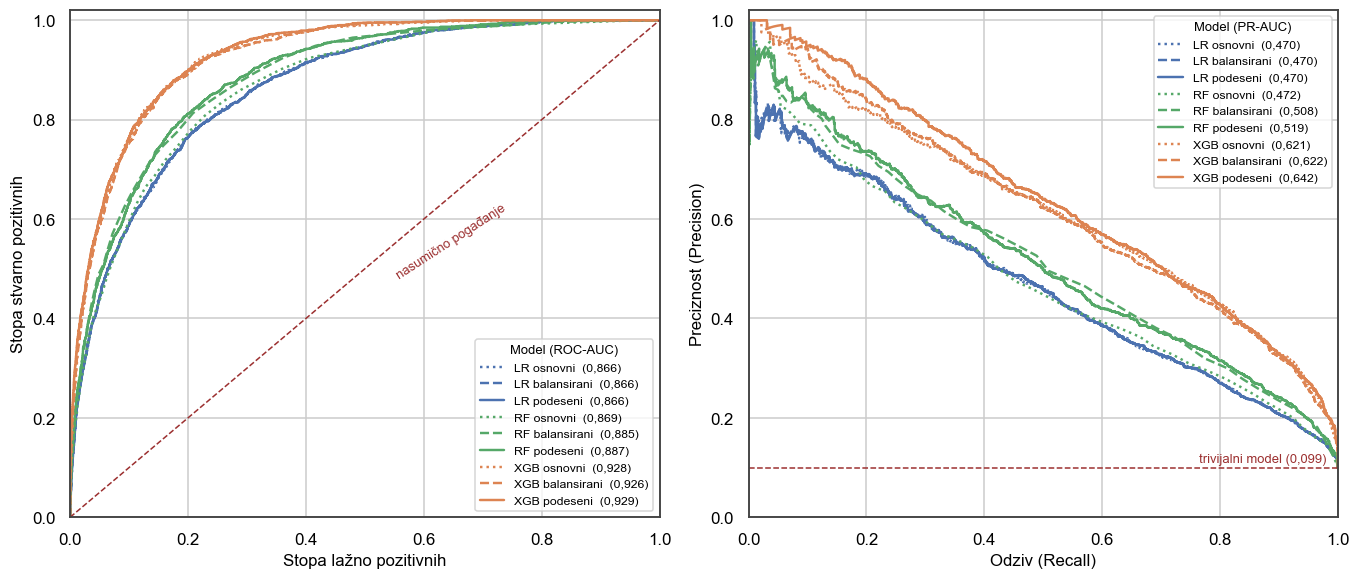

In [40]:

BOJA_ALG = {'LR': '#4C72B0', 'RF': '#55A868', 'XGB': '#DD8452'}
STIL_VAR = {'osnovni': ':', 'balansirani': '--', 'podeseni': '-'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.4))
udeo_pozitivnih = y_test.mean()

for naziv in zbirna['Model']:
    alg, var = naziv.split(' ', 1)
    p = verovatnoce_modela[naziv]
    boja, stil = BOJA_ALG[alg], STIL_VAR[var]

    fpr, tpr, _ = roc_curve(y_test, p)
    ax1.plot(fpr, tpr, color=boja, ls=stil, lw=1.6,
             label=f'{naziv}  ({roc_auc_score(y_test, p):.3f})'.replace('.', ','))

    prec, rec, _ = precision_recall_curve(y_test, p)
    ax2.plot(rec, prec, color=boja, ls=stil, lw=1.6,
             label=f'{naziv}  ({average_precision_score(y_test, p):.3f})'.replace('.', ','))

ax1.plot([0, 1], [0, 1], color='#9c3030', ls='--', lw=1.0)
ax1.text(0.55, 0.48, 'nasumično pogađanje', color='#9c3030', fontsize=8.5, rotation=33)
ax1.set_xlabel('Stopa lažno pozitivnih')
ax1.set_ylabel('Stopa stvarno pozitivnih')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1.02)
ax1.legend(title='Model (ROC-AUC)', fontsize=8, title_fontsize=8.5, loc='lower right')

ax2.axhline(udeo_pozitivnih, color='#9c3030', ls='--', lw=1.0)
ax2.text(0.98, udeo_pozitivnih + 0.012,
         f'trivijalni model ({udeo_pozitivnih:.3f})'.replace('.', ','),
         color='#9c3030', fontsize=8.5, ha='right')
ax2.set_xlabel('Odziv (Recall)')
ax2.set_ylabel('Preciznost (Precision)')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.02)
ax2.legend(title='Model (PR-AUC)', fontsize=8, title_fontsize=8.5, loc='upper right')

fig.tight_layout()
sacuvaj('slika_08_roc_i_pr_krive')
plt.show()

## DOPUNA TABELE SA PR-AUC

In [41]:
zbirna['PR-AUC'] = [round(average_precision_score(y_test, verovatnoce_modela[m]), 4)
                    for m in zbirna['Model']]

zbirna.to_csv(TABELE / 'tabela_12_zbirni_rezultati.csv',
              index=False, encoding='utf-8-sig')

print(f'Trivijalni PR-AUC (udeo pozitivnih): {y_test.mean():.4f}\n')
zbirna[['Model', 'F1', 'ROC-AUC', 'PR-AUC']]

Trivijalni PR-AUC (udeo pozitivnih): 0.0988



,Model,F1,ROC-AUC,PR-AUC
0,LR osnovni,0.3524,0.8658,0.4703
1,LR balansirani,0.4120,0.8656,0.4700
2,LR podeseni,0.4118,0.8656,0.4701
3,RF osnovni,0.1027,0.8688,0.4720
4,RF balansirani,0.1086,0.8846,0.5083
5,RF podeseni,0.4984,0.8868,0.5190
6,XGB osnovni,0.5164,0.9275,0.6208
7,XGB balansirani,0.5663,0.9256,0.6220
8,XGB podeseni,0.5849,0.9292,0.6421


## E3 - Konfuziona matrica

Sacuvano: slike/slika_09_matrice_konfuzije.png


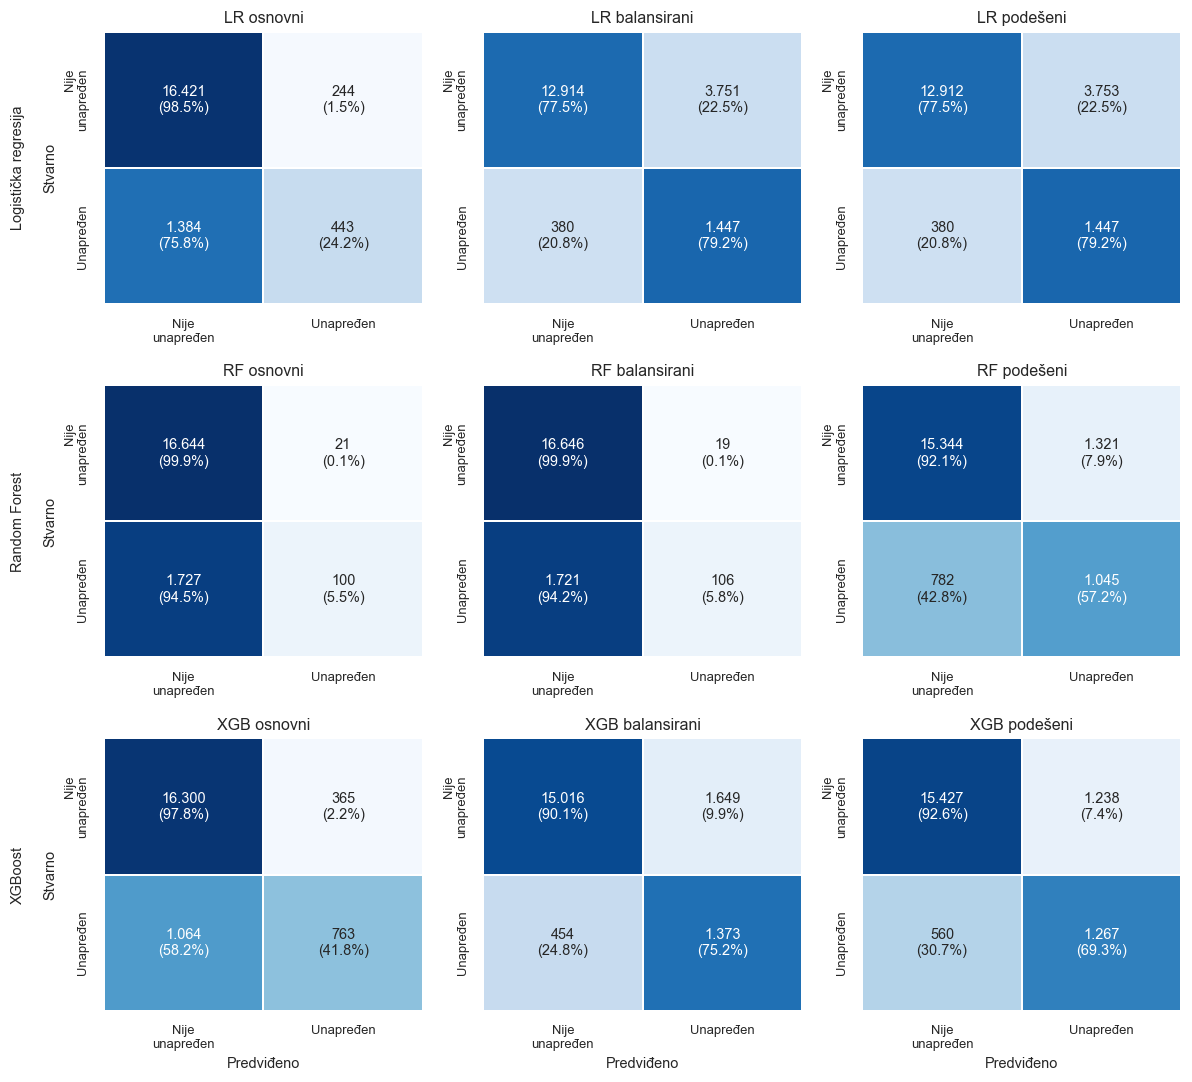

In [42]:
sns.set_theme(style='white')
OZNAKE = ['Nije\nunapređen', 'Unapređen']

fig, axes = plt.subplots(3, 3, figsize=(11, 10))

for i, (a, a_naz) in enumerate(zip(['LR', 'RF', 'XGB'], ALG_NAZ)):
    for j, (v, v_naz) in enumerate(zip(VAR, VAR_NAZ)):
        naziv = f'{a} {v}'
        pred = (verovatnoce_modela[naziv] >= 0.5).astype(int)
        cm = confusion_matrix(y_test, pred)
        cm_norm = cm / cm.sum(axis=1, keepdims=True)

        anot = np.empty_like(cm).astype(object)
        for r in range(2):
            for c in range(2):
                anot[r, c] = f'{cm[r, c]:,}\n({cm_norm[r, c] * 100:.1f}%)'.replace(',', '.')

        ax = axes[i, j]
        sns.heatmap(cm_norm, annot=anot, fmt='', cmap='Blues', vmin=0, vmax=1,
                    cbar=False, linewidths=1.2, linecolor='white',
                    annot_kws={'fontsize': 9.5}, ax=ax,
                    xticklabels=OZNAKE, yticklabels=OZNAKE)
        ax.set_title(f'{a} {v_naz}', fontsize=10.5, pad=6)
        ax.tick_params(labelsize=8.5)
        ax.set_ylabel(f'{a_naz}\n\nStvarno' if j == 0 else '', fontsize=9.5)
        ax.set_xlabel('Predviđeno' if i == 2 else '', fontsize=9.5)

fig.tight_layout()
sacuvaj('slika_09_matrice_konfuzije')
plt.show()

sns.set_theme(style='whitegrid')   # vracamo stil za naredne grafikone

### TABELA SA BROJEVIMA

In [43]:
redovi = []
for naziv in zbirna['Model']:
    tn, fp, fn, tp = confusion_matrix(
        y_test, (verovatnoce_modela[naziv] >= 0.5).astype(int)).ravel()
    redovi.append({
        'Model': naziv,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Uhvaceno unapredjenih': f'{tp} / {tp + fn}',
        'Laznih uzbuna po pogotku': round(fp / tp, 2) if tp else None,
    })

matrice = pd.DataFrame(redovi)
matrice.to_csv(TABELE / 'tabela_13_matrice_konfuzije.csv',
               index=False, encoding='utf-8-sig')
print('Sacuvano: tabele/tabela_13_matrice_konfuzije.csv')
matrice

Sacuvano: tabele/tabela_13_matrice_konfuzije.csv


,Model,TN,FP,FN,TP,Uhvaceno unapredjenih,Laznih uzbuna po pogotku
0,LR osnovni,16421,244,1384,443,443 / 1827,0.55
1,LR balansirani,12914,3751,380,1447,1447 / 1827,2.59
2,LR podeseni,12912,3753,380,1447,1447 / 1827,2.59
3,RF osnovni,16644,21,1727,100,100 / 1827,0.21
4,RF balansirani,16646,19,1721,106,106 / 1827,0.18
5,RF podeseni,15344,1321,782,1045,1045 / 1827,1.26
6,XGB osnovni,16300,365,1064,763,763 / 1827,0.48
7,XGB balansirani,15016,1649,454,1373,1373 / 1827,1.20
8,XGB podeseni,15427,1238,560,1267,1267 / 1827,0.98


## E4 — McNemarov test

In [44]:
tacno = {n: ((verovatnoce_modela[n] >= 0.5).astype(int) == y_test.values)
         for n in zbirna['Model']}

parovi = list(combinations(zbirna['Model'], 2))
ALFA = 0.05
ALFA_BONF = ALFA / len(parovi)          # Bonferronijeva korekcija

redovi = []
for a, b in parovi:
    ta, tb = tacno[a], tacno[b]
    n10 = int(np.sum(ta & ~tb))         # A tacan, B gresi
    n01 = int(np.sum(~ta & tb))         # A gresi, B tacan
    rez = mcnemar([[int(np.sum(ta & tb)), n10],
                   [n01, int(np.sum(~ta & ~tb))]], exact=False, correction=True)
    redovi.append({
        'Model A': a, 'Model B': b,
        'A tacan, B gresi': n10, 'A gresi, B tacan': n01,
        'Neslaganja': n01 + n10,
        'hi-kvadrat': round(float(rez.statistic), 2),
        'p-vrednost': float(rez.pvalue),
        'Znacajno': 'da' if rez.pvalue < ALFA_BONF else 'ne',
    })

mcnemar_tab = pd.DataFrame(redovi)
mcnemar_tab.to_csv(TABELE / 'tabela_14_mcnemar.csv', index=False, encoding='utf-8-sig')

print(f'Parova: {len(parovi)} | alfa = {ALFA} | Bonferroni: {ALFA_BONF:.5f}')
print(f'Znacajnih razlika: {(mcnemar_tab["Znacajno"] == "da").sum()} od {len(parovi)}\n')
print('PAROVI BEZ ZNACAJNE RAZLIKE:')
print(mcnemar_tab[mcnemar_tab['Znacajno'] == 'ne']
      [['Model A', 'Model B', 'Neslaganja', 'p-vrednost']].to_string(index=False))

Parova: 36 | alfa = 0.05 | Bonferroni: 0.00139
Znacajnih razlika: 31 od 36

PAROVI BEZ ZNACAJNE RAZLIKE:
       Model A         Model B  Neslaganja  p-vrednost
LR balansirani     LR podeseni           8    0.723674
    RF osnovni  RF balansirani         134    0.545373
    RF osnovni    XGB podeseni        2388    0.315997
RF balansirani    XGB podeseni        2382    0.242849
   RF podeseni XGB balansirani        1886    0.981629


### PRIKAZ REZULTATA

Sacuvano: slike/slika_10_mcnemar.png


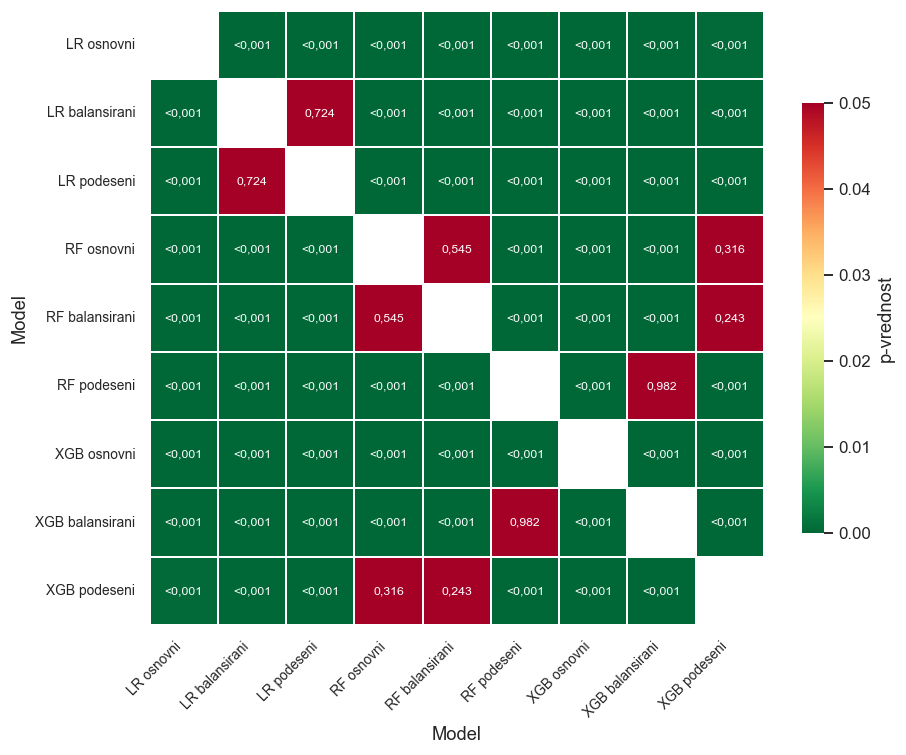

In [45]:
M = pd.DataFrame(np.nan, index=zbirna['Model'], columns=zbirna['Model'])
for r in redovi:
    M.loc[r['Model A'], r['Model B']] = r['p-vrednost']
    M.loc[r['Model B'], r['Model A']] = r['p-vrednost']

anot = M.map(lambda v: '' if pd.isna(v) else ('<0,001' if v < 0.001 else f'{v:.3f}'.replace('.', ',')))

sns.set_theme(style='white')
fig, ax = plt.subplots(figsize=(8.6, 7))
sns.heatmap(M, mask=M.isna(), annot=anot, fmt='', cmap='RdYlGn_r',
            vmin=0, vmax=0.05, linewidths=1.2, linecolor='white',
            annot_kws={'fontsize': 8}, square=True,
            cbar_kws={'label': 'p-vrednost', 'shrink': 0.7}, ax=ax)
ax.tick_params(labelsize=9)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()
sacuvaj('slika_10_mcnemar')
plt.show()
sns.set_theme(style='whitegrid')

### Dopuna: bootstrap za razliku u F1

In [46]:
B = 1000
n = len(y_test)
yv = y_test.values

def bootstrap_f1(predikcije):
    """Raspodela mere F1 na B ponovljenih uzoraka test skupa.
    Generator se pokrece iz istog semena pri svakom pozivu, pa svi modeli
    dobijaju iste uzorke. Uparivanje je neophodno jer se modeli porede na
    istom test skupu; bez njega interval poverenja razlike ispada siri.
    """
    rng = np.random.default_rng(RANDOM_STATE)
    out = np.empty(B)
    for i in range(B):
        idx = rng.integers(0, n, n)
        yb, pb = yv[idx], predikcije[idx]
        tp = np.sum((pb == 1) & (yb == 1))
        fp = np.sum((pb == 1) & (yb == 0))
        fn = np.sum((pb == 0) & (yb == 1))
        out[i] = 2 * tp / (2 * tp + fp + fn) if tp else 0.0
    return out

raspodele = {n_: bootstrap_f1((verovatnoce_modela[n_] >= 0.5).astype(int))
             for n_ in zbirna['Model']}

redovi_b = []
for a, b in parovi:
    d = raspodele[a] - raspodele[b]
    lo, hi = np.percentile(d, [2.5, 97.5])
    redovi_b.append({
        'Model A': a, 'Model B': b,
        'Razlika F1': round(d.mean(), 4),
        'Donja granica': round(lo, 4),
        'Gornja granica': round(hi, 4),
        'Znacajno': 'da' if lo * hi > 0 else 'ne',
    })

bootstrap_tab = pd.DataFrame(redovi_b)
bootstrap_tab.to_csv(TABELE / 'tabela_15_bootstrap_f1.csv',
                     index=False, encoding='utf-8-sig')
print(f'Znacajnih razlika u F1: {(bootstrap_tab["Znacajno"] == "da").sum()} od {len(parovi)}')
bootstrap_tab.head(10)

Znacajnih razlika u F1: 33 od 36


,Model A,Model B,Razlika F1,Donja granica,Gornja granica,Znacajno
0,LR osnovni,LR balansirani,-0.0601,-0.0853,-0.0335,da
1,LR osnovni,LR podeseni,-0.0600,-0.0850,-0.0333,da
2,LR osnovni,RF osnovni,0.2489,0.2250,0.2743,da
3,LR osnovni,RF balansirani,0.2430,0.2188,0.2684,da
4,LR osnovni,RF podeseni,-0.1465,-0.1704,-0.1225,da
5,LR osnovni,XGB osnovni,-0.1640,-0.1881,-0.1380,da
6,LR osnovni,XGB balansirani,-0.2141,-0.2379,-0.1877,da
7,LR osnovni,XGB podeseni,-0.2327,-0.2568,-0.2076,da
8,LR balansirani,LR podeseni,0.0001,-0.0002,0.0005,ne
9,LR balansirani,RF osnovni,0.3090,0.2835,0.3321,da


# F - Produbljivanje analize: prag i značajnost atributa

## F1 - PRAG


In [47]:
PRAGOVI = np.arange(0.02, 0.99, 0.01)

def najbolji_prag(y_stvarno, verovatnoce):
    f = [f1_score(y_stvarno, (verovatnoce >= t).astype(int), zero_division=0)
         for t in PRAGOVI]
    return PRAGOVI[int(np.argmax(f))]

redovi, krive_praga = [], {}

for naziv in zbirna['Model']:
    model = joblib.load(MODELI / f'{naziv}.joblib')
    atributi = ATRIBUTI_LOGREG if naziv.startswith('LR') else ATRIBUTI_STABLA

    # prag se bira ISKLJUCIVO na trening skupu, preko predikcija van preklopa
    p_cv = cross_val_predict(model, X_train[atributi], y_train, cv=CV,
                             method='predict_proba', n_jobs=1)[:, 1]
    prag = najbolji_prag(y_train.values, p_cv)

    p_te = verovatnoce_modela[naziv]
    krive_praga[naziv] = [f1_score(y_test, (p_te >= t).astype(int), zero_division=0)
                          for t in PRAGOVI]

    pred_opt = (p_te >= prag).astype(int)
    redovi.append({
        'Model': naziv,
        'Prag': round(float(prag), 2),
        'F1 (prag 0,5)': round(f1_score(y_test, (p_te >= 0.5).astype(int)), 4),
        'F1 (optimalan prag)': round(f1_score(y_test, pred_opt), 4),
        'Precision': round(precision_score(y_test, pred_opt, zero_division=0), 4),
        'Recall': round(recall_score(y_test, pred_opt), 4),
        'Accuracy': round(accuracy_score(y_test, pred_opt), 4),
    })
    print(f'  {naziv:16s} prag={prag:.2f}')

pragovi_tab = pd.DataFrame(redovi)
pragovi_tab['Dobitak'] = (pragovi_tab['F1 (optimalan prag)']
                          - pragovi_tab['F1 (prag 0,5)']).round(4)
pragovi_tab.to_csv(TABELE / 'tabela_16_optimizacija_praga.csv',
                   index=False, encoding='utf-8-sig')
print()
pragovi_tab

  LR osnovni       prag=0.24
  LR balansirani   prag=0.76
  LR podeseni      prag=0.75
  RF osnovni       prag=0.23
  RF balansirani   prag=0.19
  RF podeseni      prag=0.49
  XGB osnovni      prag=0.24
  XGB balansirani  prag=0.64
  XGB podeseni     prag=0.56



,Model,Prag,"F1 (prag 0,5)",F1 (optimalan prag),Precision,Recall,Accuracy,Dobitak
0,LR osnovni,0.24,0.3524,0.4764,0.4342,0.5276,0.8854,0.1240
1,LR balansirani,0.76,0.4120,0.4808,0.4491,0.5172,0.8896,0.0688
2,LR podeseni,0.75,0.4118,0.4767,0.4340,0.5287,0.8853,0.0649
3,RF osnovni,0.23,0.1027,0.4743,0.4261,0.5348,0.8829,0.3716
4,RF balansirani,0.19,0.1086,0.5098,0.4451,0.5966,0.8867,0.4012
5,RF podeseni,0.49,0.4984,0.4938,0.4262,0.5868,0.8811,-0.0046
6,XGB osnovni,0.24,0.5164,0.5865,0.5263,0.6623,0.9077,0.0701
7,XGB balansirani,0.64,0.5663,0.5785,0.5182,0.6546,0.9057,0.0122
8,XGB podeseni,0.56,0.5849,0.5905,0.5396,0.6519,0.9107,0.0056


Sacuvano: slike/slika_11_optimizacija_praga.png


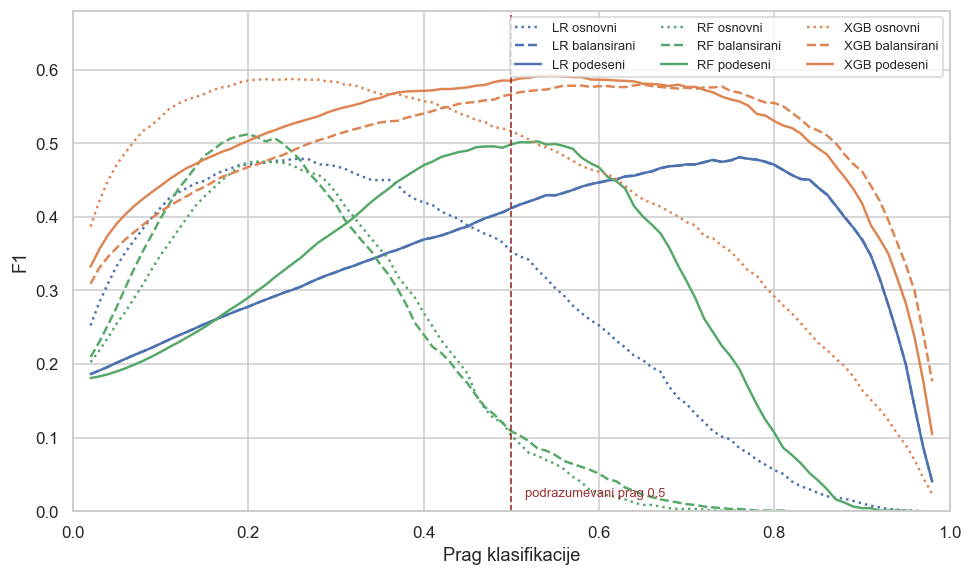

In [48]:
fig, ax = plt.subplots(figsize=(9, 5.4))
for naziv in zbirna['Model']:
    a, v = naziv.split(' ', 1)
    ax.plot(PRAGOVI, krive_praga[naziv], color=BOJA_ALG[a], ls=STIL_VAR[v],
            lw=1.6, label=naziv)

ax.axvline(0.5, color='#9c3030', ls='--', lw=1.1)
ax.text(0.515, 0.02, 'podrazumevani prag 0,5', color='#9c3030', fontsize=8.5)
ax.set_xlabel('Prag klasifikacije')
ax.set_ylabel('F1')
ax.set_xlim(0, 1); ax.set_ylim(0, 0.68)
ax.legend(fontsize=8.5, ncol=3, loc='upper right')

fig.tight_layout()
sacuvaj('slika_11_optimizacija_praga')
plt.show()

## F2 — Pojedinačna važnost atributa - PERMUTACIONA VAŽNOST

  LR podeseni gotovo
  RF podeseni gotovo
  XGB podeseni gotovo
Sacuvano: slike/slika_12_vaznost_atributa.png


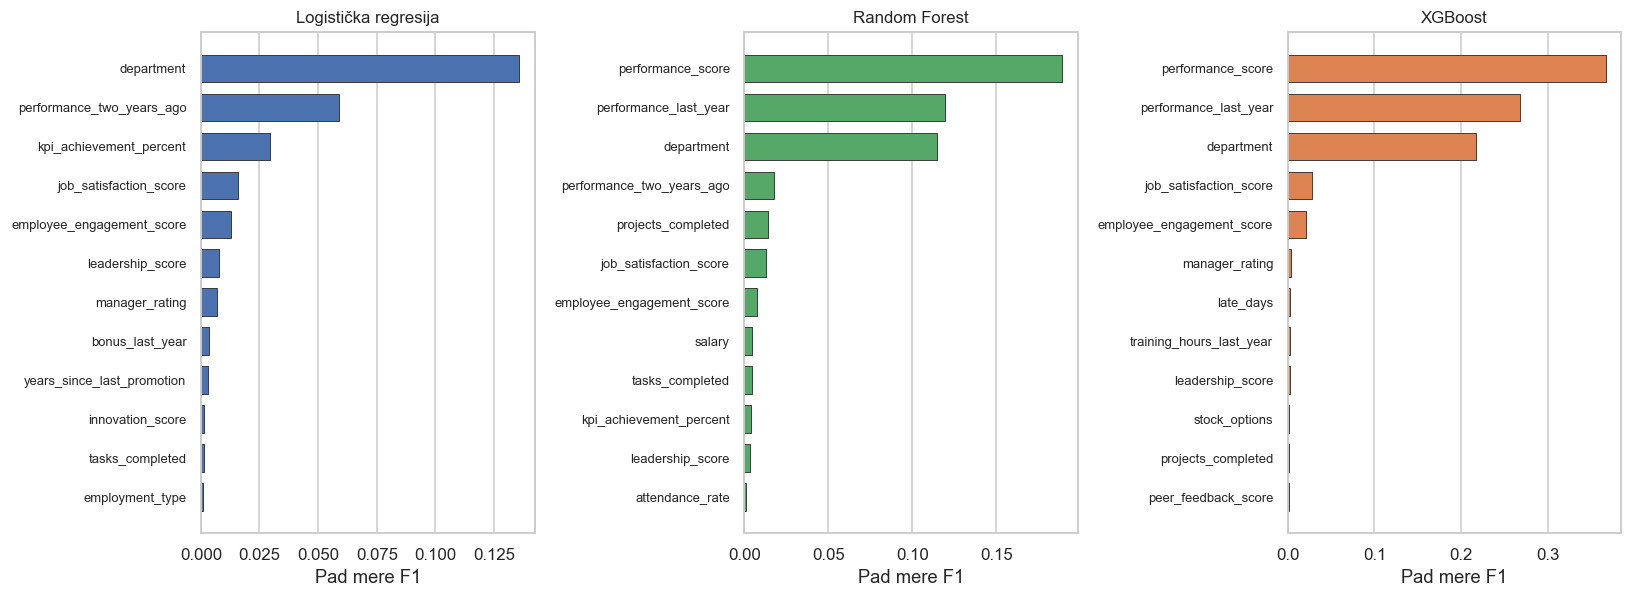

In [49]:
NAJBOLJI = ['LR podeseni', 'RF podeseni', 'XGB podeseni']
NAZ_ALG = ['Logistička regresija', 'Random Forest', 'XGBoost']

vaznosti = {}
for naziv in NAJBOLJI:
    model = joblib.load(MODELI / f'{naziv}.joblib')
    atributi = ATRIBUTI_LOGREG if naziv.startswith('LR') else ATRIBUTI_STABLA
    r = permutation_importance(model, X_test[atributi], y_test, scoring='f1',
                               n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
    vaznosti[naziv] = pd.Series(r.importances_mean, index=atributi).sort_values(ascending=False)
    print(f'  {naziv} gotovo')

pd.DataFrame(vaznosti).round(4).to_csv(
    TABELE / 'tabela_17_vaznost_atributa.csv', encoding='utf-8-sig', index_label='Atribut')

fig, axes = plt.subplots(1, 3, figsize=(15, 5.6))
for ax, naziv, naz in zip(axes, NAJBOLJI, NAZ_ALG):
    v = vaznosti[naziv].head(12)[::-1]
    ax.barh(range(len(v)), v.values, color=BOJA_ALG[naziv.split()[0]],
            edgecolor='#333333', linewidth=0.6, height=0.7)
    ax.set_yticks(range(len(v)))
    ax.set_yticklabels(v.index, fontsize=8.5)
    ax.set_title(naz, fontsize=11, pad=6)
    ax.set_xlabel('Pad mere F1')
    ax.grid(axis='y', visible=False)

fig.tight_layout()
sacuvaj('slika_12_vaznost_atributa')
plt.show()

### Grupna važnost po blokovima

Sacuvano: slike/slika_13_vaznost_po_blokovima.png


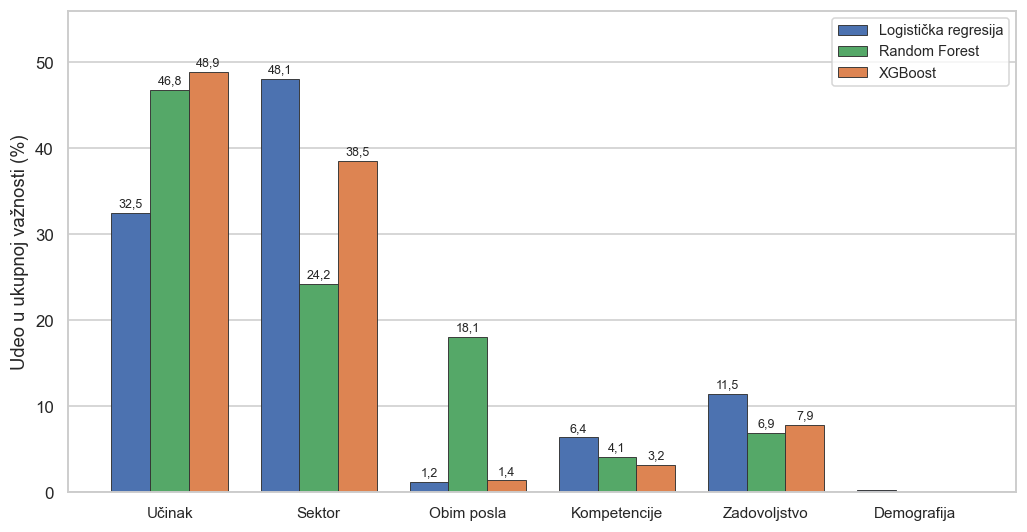

,Logistička regresija,Random Forest,XGBoost
Učinak,32.5,46.8,48.9
Sektor,48.1,24.2,38.5
Obim posla,1.2,18.1,1.4
Kompetencije,6.4,4.1,3.2
Zadovoljstvo,11.5,6.9,7.9
Demografija,0.3,0.0,0.0


In [50]:
BLOKOVI = {
    'Učinak': ['performance_score', 'performance_last_year', 'performance_two_years_ago',
               'kpi_achievement_percent', 'manager_rating', 'peer_feedback_score',
               'bonus_last_year'],
    'Sektor': ['department'],
    'Obim posla': ['projects_completed', 'tasks_completed', 'avg_monthly_hours', 'salary'],
    'Kompetencije': ['leadership_score', 'innovation_score', 'skill_assessment_score',
                     'stock_options'],
    'Zadovoljstvo': ['job_satisfaction_score', 'employee_engagement_score',
                     'internal_mobility_score'],
    'Demografija': ['age', 'gender', 'education_level', 'marital_status', 'city_tier'],
}

def grupna_vaznost(model, atributi, n_ponavljanja=5):
    rng = np.random.default_rng(RANDOM_STATE)
    Xk = X_test[atributi]
    osnovni = average_precision_score(y_test, model.predict_proba(Xk)[:, 1])
    out = {}
    for naziv, lista in BLOKOVI.items():
        prisutni = [a for a in lista if a in atributi]
        padovi = []
        for _ in range(n_ponavljanja):
            Xp = Xk.copy()
            Xp[prisutni] = Xp[prisutni].values[rng.permutation(len(Xp))]  # ceo blok zajedno
            padovi.append(osnovni - average_precision_score(y_test, model.predict_proba(Xp)[:, 1]))
        out[naziv] = np.mean(padovi)
    return out

grupno = pd.DataFrame({
    naziv: grupna_vaznost(joblib.load(MODELI / f'{naziv}.joblib'),
                          ATRIBUTI_LOGREG if naziv.startswith('LR') else ATRIBUTI_STABLA)
    for naziv in NAJBOLJI
}).reindex(list(BLOKOVI))

udeo = (grupno.clip(lower=0) / grupno.clip(lower=0).sum() * 100).round(1)
udeo.columns = NAZ_ALG
udeo.to_csv(TABELE / 'tabela_18_vaznost_po_blokovima.csv', encoding='utf-8-sig', index_label='Blok')

fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(udeo))
for i, (kol, boja) in enumerate(zip(udeo.columns, ['#4C72B0', '#55A868', '#DD8452'])):
    st = ax.bar(x + (i - 1) * 0.26, udeo[kol], 0.26, label=kol, color=boja,
                edgecolor='#333333', linewidth=0.6)
    for s, v in zip(st, udeo[kol]):
        if v >= 1:
            ax.text(s.get_x() + s.get_width() / 2, v + 0.7,
                    f'{v:.1f}'.replace('.', ','), ha='center', fontsize=8.2)
ax.set_xticks(x); ax.set_xticklabels(udeo.index, fontsize=10)
ax.set_ylabel('Udeo u ukupnoj važnosti (%)')
ax.set_ylim(0, 56); ax.grid(axis='x', visible=False)
ax.legend(fontsize=9.5)
fig.tight_layout()
sacuvaj('slika_13_vaznost_po_blokovima')
plt.show()
udeo